###Context
* You're working at BCG as Data Scientist
* Your team has been assigned a new project for a client called PowerCo
* Your client is PowerCo - a major gas and electricity utility that supplies to small and medium sized enterprises.
* The energy market has had a lot of change in recent years and there are more options than ever for customers to choose from.
* PowerCo are concerned about their customers leaving for better offers from other energy providers. When a customer leaves to use another service provider, this is called churn.
* This is becoming a big issue for PowerCo and they have engaged BCG to help diagnose the reason why their customers are churning.
* Some potential reasons for this churn, one being how “sensitive” the price is. In other words, how much is price a factor in a customer’s choice to stay with or leave PowerCo?

In order to test the hypothesis of whether churn is driven by the customers’ price sensitivity, we would need to model churn probabilities of customers, and derive the effect of prices on churn rates.

We would need the following data to be able to build the models.

* Customer data - which should include characteristics of each client, for example, industry, historical electricity consumption, date joined as customer etc.
* Churn data - which should indicate if customer has churned
* Historical price data – which should indicate the prices the client charges to each customer for both electricity and gas at granular time intervals


Once we have the data, the work plan would be:

* We need to define what price sensitivity is and calculate it
* We need to prepare the data and engineer features
* Then, we can test our hypothesis using a binary classification model (e.g. Logistic Regression, Random Forest, Gradient Boosted Machines to name a few)
* We would choose a model from one of the tested algorithms based on the model complexity, the explainability, and the accuracy of the models.
* With the trained model, we would be able to extrapolate the extent to which price sensitivity influences churn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

###EDA and Data Cleaning

Next task will be to investigate whether price sensitivity is the most influential factor for a customer churning, and if not, to what extent price sensitivity influences churn.


Before we begin on this task, it is important that we are clear about what we mean when we talk about price sensitivity.

* **Price sensitivity** is the degree to which customer behaviors change in response to a change in price. In other words, how much do PowerCo’s customers react when prices go up?

Sensitivity is often quantified using the price elasticity of demand formula which is [% change in quantity demanded / % change in price].

As a general rule, if the absolute value of the price elasticity of demand formula is greater than 1, the product or service would be considered elastic meaning that the price is very likely to influence how much people buy.

* **Price elasticity** of demand is a measurement of the change in consumption of a product in relation to a change in its price

The data provided by the client are:

* **Historical customer data**: Customer data such as usage, sign up date, forecasted usage etc
* **Historical pricing data**: variable and fixed pricing data at different points in time
* **Churn indicator**: whether each customer has churned or not

In [ ]:
client_data = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/client_data.csv')
price_data = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/price_data.csv')

In [ ]:
client_df = client_data.copy()
price_df = price_data.copy()

In [ ]:
client_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,t,0.00,27.88,27.88,2,381.77,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,f,15.94,0.00,0.00,1,90.34,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,f,18.05,39.84,39.84,1,20.38,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,f,0.00,13.08,13.08,1,0.96,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0


In [ ]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [ ]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [ ]:
client_df.select_dtypes(include=object).describe()

,id,channel_sales,date_activ,date_end,date_modif_prod,date_renewal,has_gas,origin_up
count,14606,14606,14606,14606,14606,14606,14606,14606
unique,14606,8,1796,368,2129,386,2,6
top,563dde550fd624d7352f3de77c0cdfcd,foosdfpfkusacimwkcsosbicdxkicaua,2009-08-01,2016-02-01,2015-11-01,2015-06-23,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,95,145,721,587,11955,7097


In [ ]:
#Find the MISSING category of channel sales
client_df['channel_sales'].value_counts()

,count
channel_sales,
foosdfpfkusacimwkcsosbicdxkicaua,6754
MISSING,3725
lmkebamcaaclubfxadlmueccxoimlema,1843
usilxuppasemubllopkaafesmlibmsdf,1375
ewpakwlliwisiwduibdlfmalxowmwpci,893
sddiedcslfslkckwlfkdpoeeailfpeds,11
epumfxlbckeskwekxbiuasklxalciiuu,3
fixdbufsefwooaasfcxdxadsiekoceaa,2


In [ ]:
#Convert dates into "datetime64" format from object
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])
client_df['date_modif_prod'] = pd.to_datetime(client_df['date_modif_prod'])
client_df['date_renewal'] = pd.to_datetime(client_df['date_renewal'])

In [ ]:
#Create a function that plots stacked barchart
def plot_stacked_bars(dataframe,title_,size_=(18,10),rot_=0,legend="upper right"):
  ax = dataframe.plot(
      kind='bar',
      stacked=True,
      figsize=size_,
      rot=rot_,
      title=title_
  )

  annotate_stacked_bars(ax,textsize=14)
  plt.legend(["Retention","Churn"],loc=legend)
  plt.ylabel("Company Base (%)")
  plt.show()


def annotate_stacked_bars(ax,pad=0.99,color="white",textsize=13):
  for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=color,
            size=textsize
        )

In [ ]:
#Plot stacked bar chart for churn

churn = client_df[['id','churn']]
churn.columns = ['Companies','churn'] #rename the columns
churn_total = churn.groupby(churn['churn']).count() #counts no. of churn for each company
churn_percentage = churn_total / churn_total.sum() * 100  #churn% = churn / sum(churn) * 100

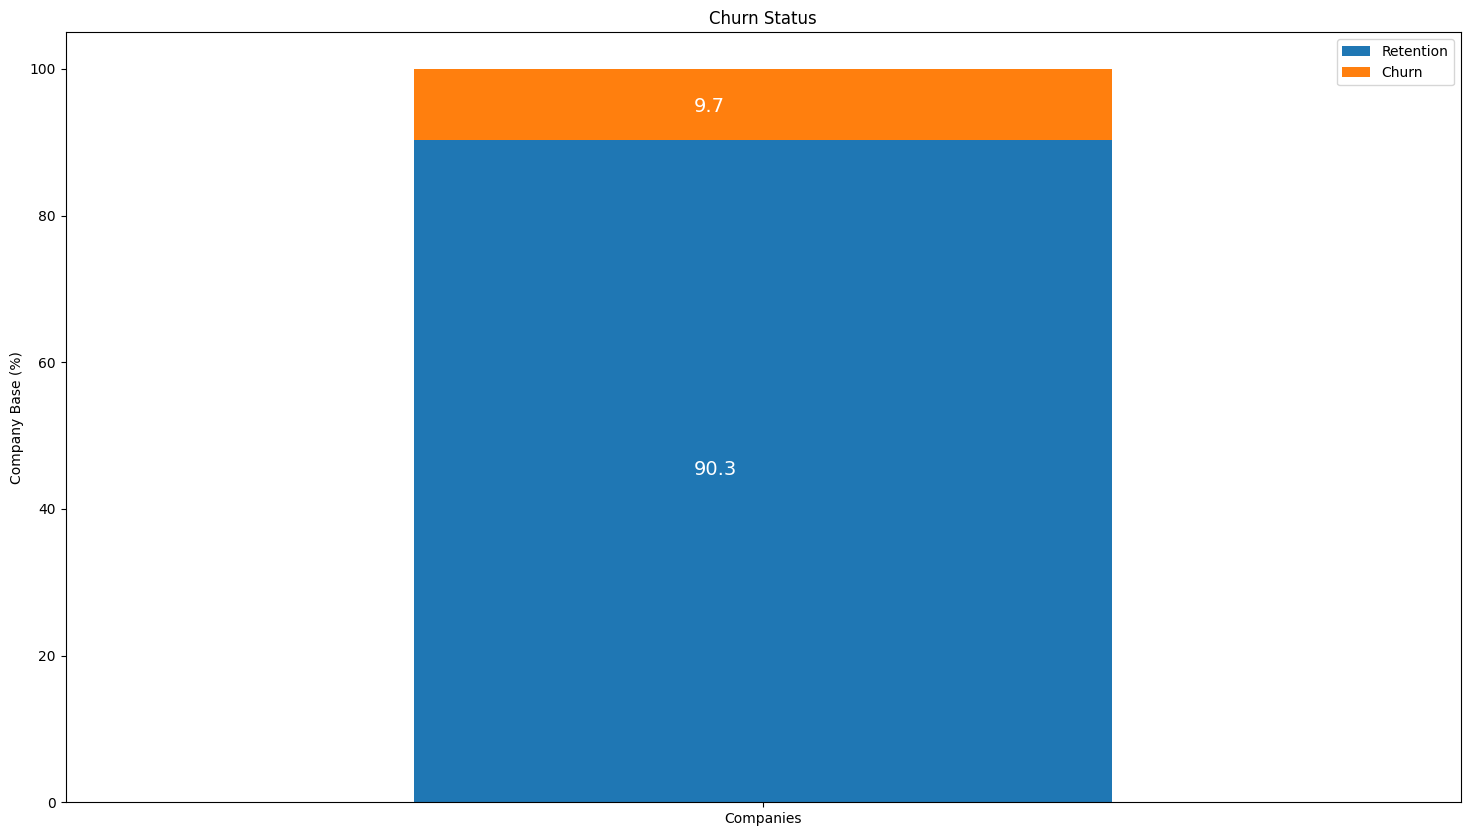

In [ ]:
plot_stacked_bars(churn_percentage.transpose(),"Churn Status")

About 10% of the total customers have churned

In [ ]:
#Plot stacked bar chart for Sales channel
channel = client_df[["id","channel_sales","churn"]]
channel = channel.groupby([channel['channel_sales'],channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1),axis=0) * 100).sort_values(by=[1],ascending=False)

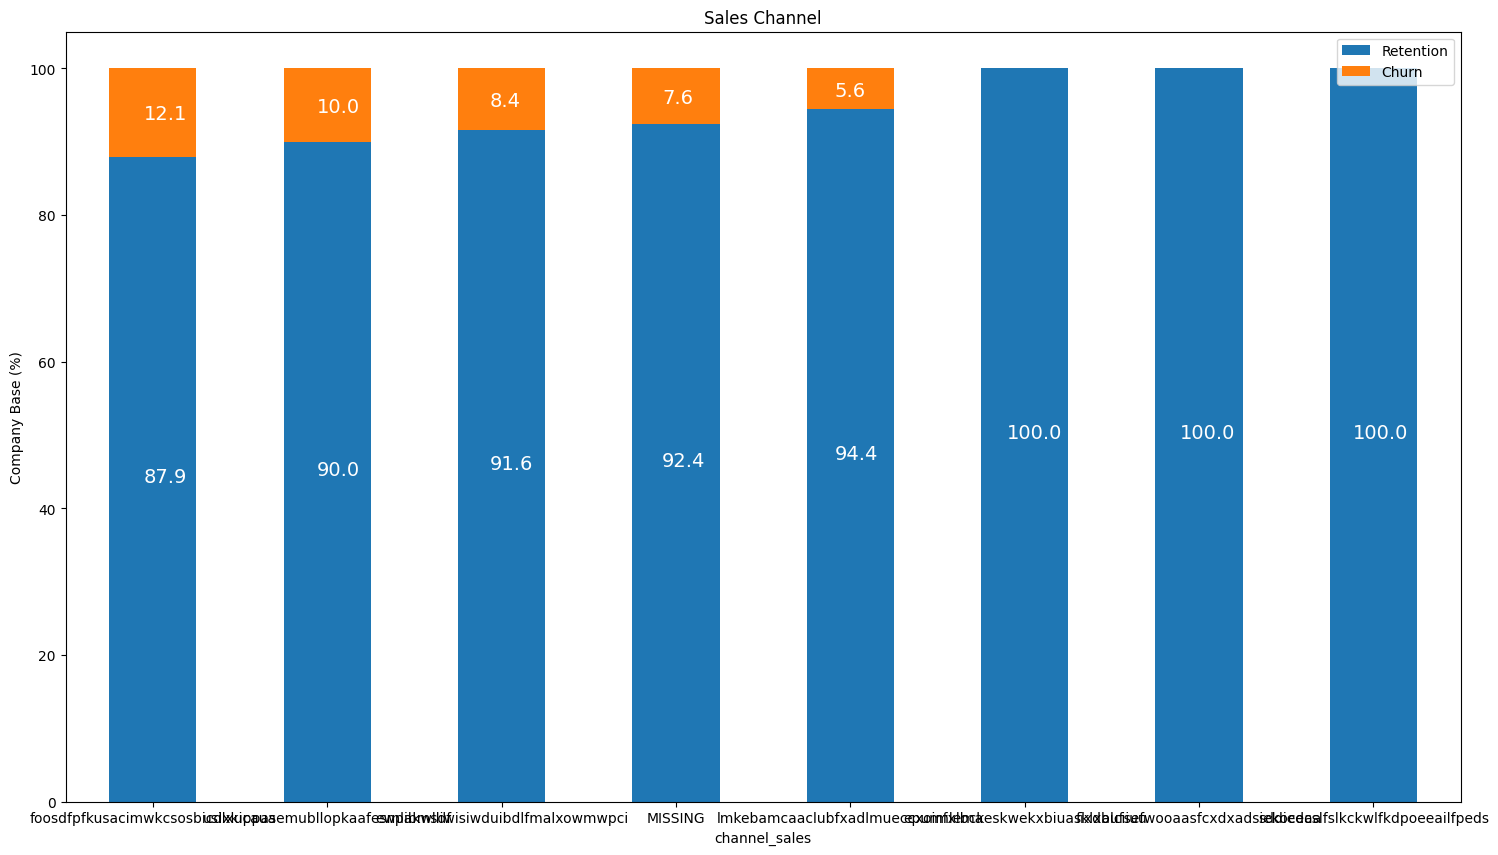

In [ ]:
plot_stacked_bars(channel_churn,"Sales Channel")

Churning customers are distributed over 5 different values for `channel_sales`.

`MISSING` has churn rate of 7.6% --> indicates that missing value was added by the team when theu were cleanig the dataset

In [ ]:
#Since consumption data is univariate , we use histogram to plot their distribution
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

In [ ]:
#Create a function that plots variable distribution in a stacked histogram of churned or retained company

def plot_distribution(dataframe,column,ax,bins_=50):
  #create the temporal df that contains the data to be plot
  temp = pd.DataFrame({"Retention":dataframe[dataframe["churn"]==0][column],
                       "Churn":dataframe[dataframe["churn"]==1][column]})
  #Plot the histogram
  temp[["Retention","Churn"]].plot(kind="hist",bins=bins_,ax=ax,stacked=True)
  ax.set_xlabel(column)
  #Chnage the x-axis to plain style
  ax.ticklabel_format(style='plain',axis='x')

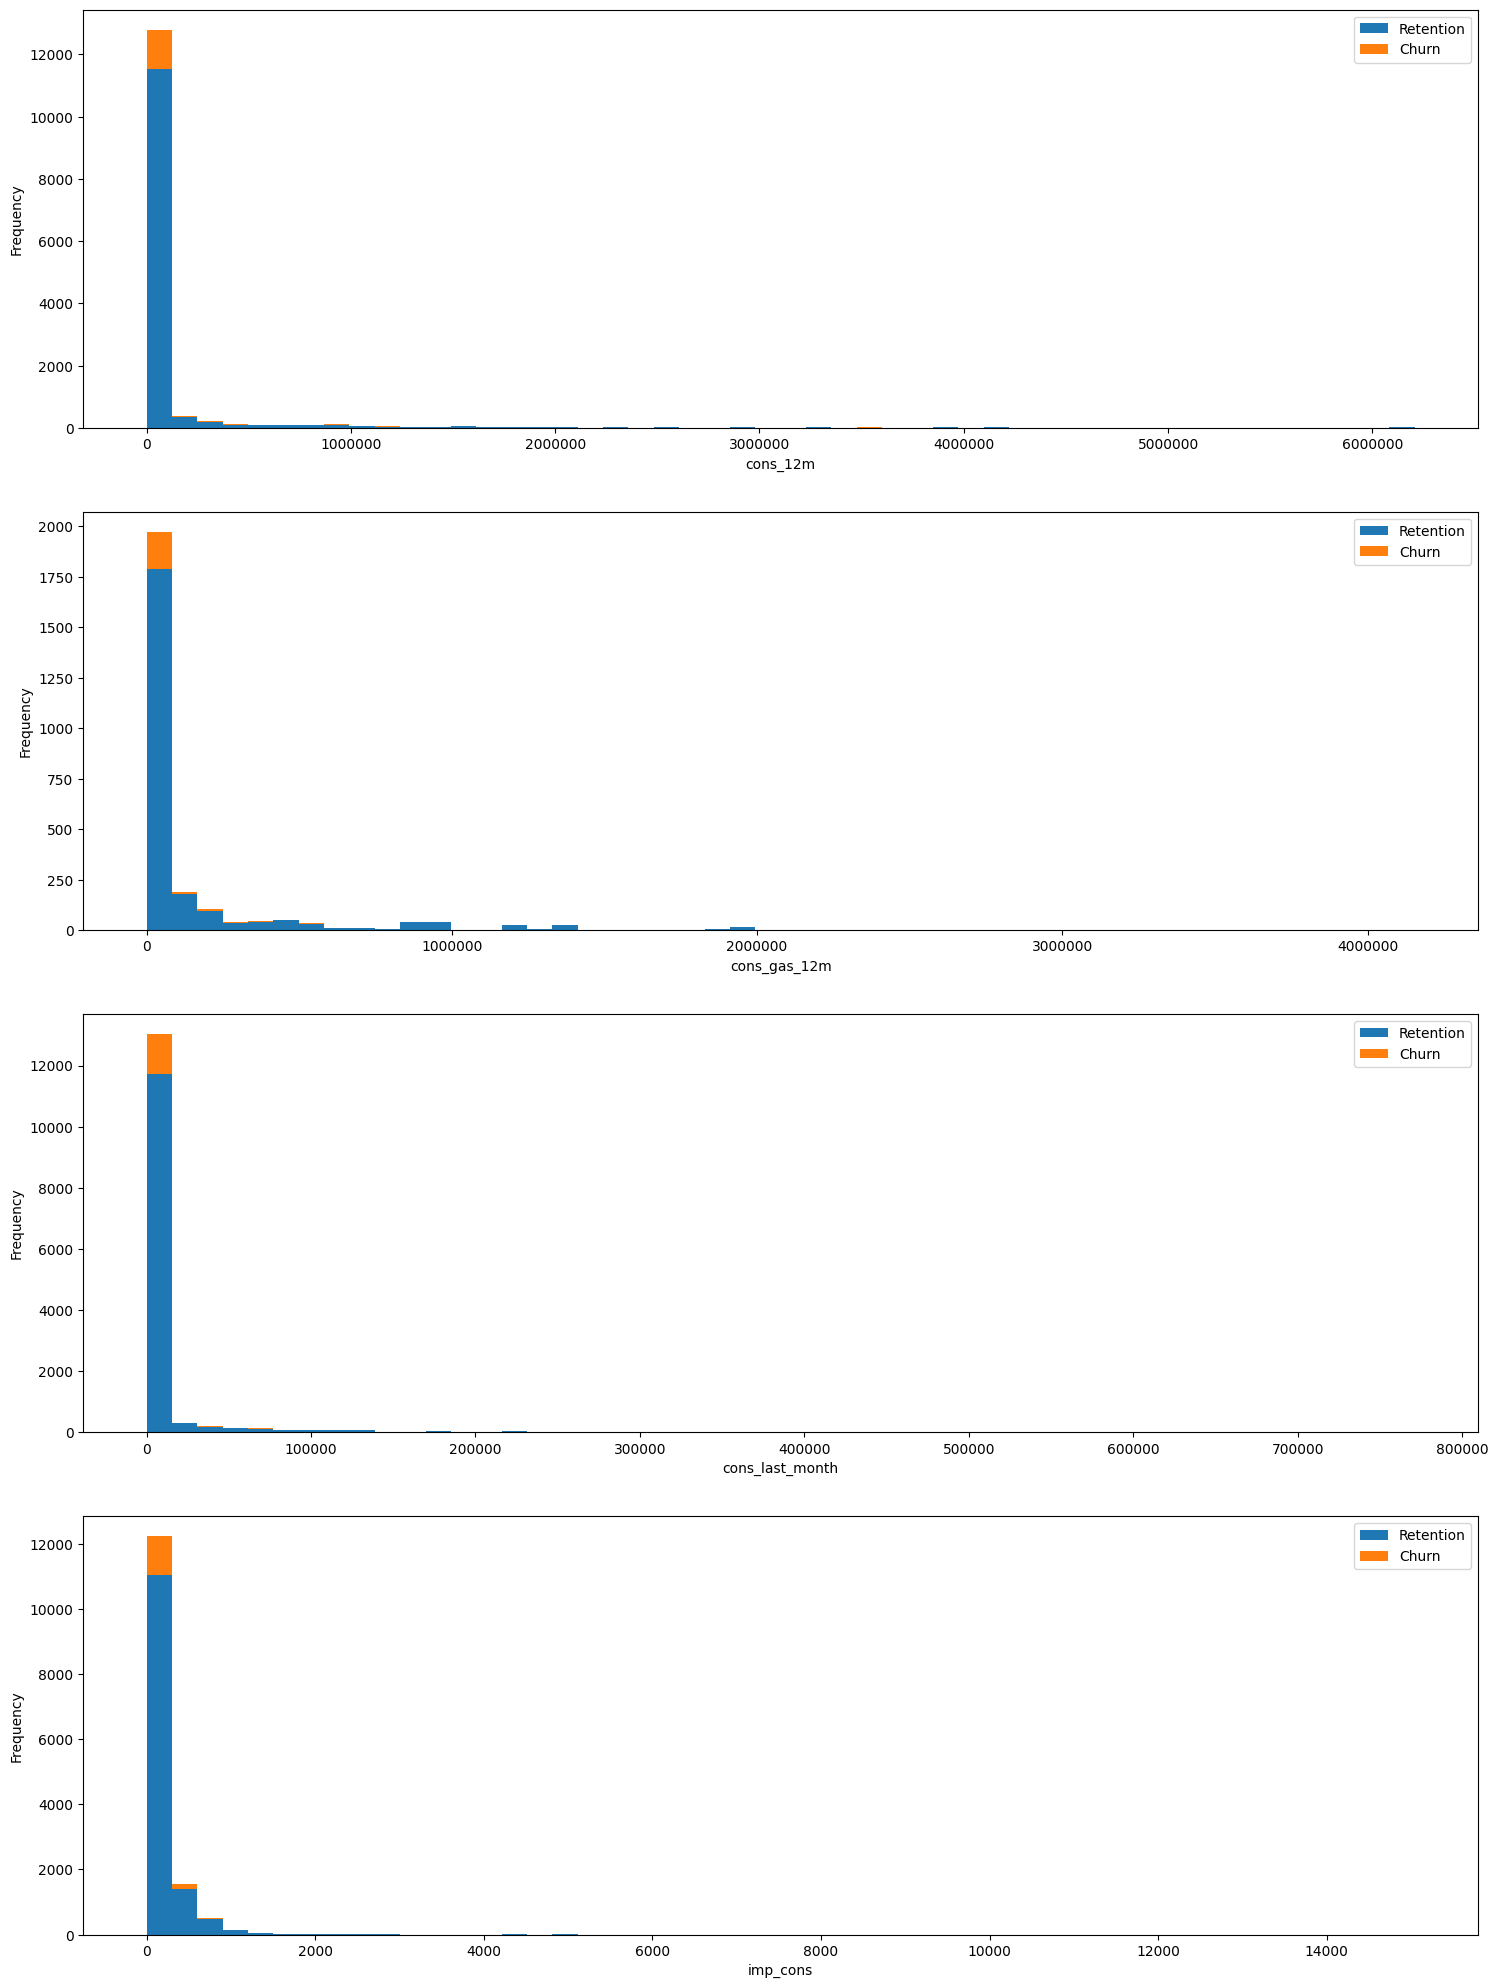

In [ ]:
fig,axs = plt.subplots(nrows=4,figsize=(18,25))

plot_distribution(consumption,"cons_12m",axs[0])
plot_distribution(consumption[consumption["has_gas"]=='t'],'cons_gas_12m',axs[1])
plot_distribution(consumption,'cons_last_month',axs[2])
plot_distribution(consumption,'imp_cons',axs[3])

Clearly, the consumption data is positively skewed, presenting a very long right-tail towards the higher-values of the distribution.

The values on the lower end are likely ro be outliers

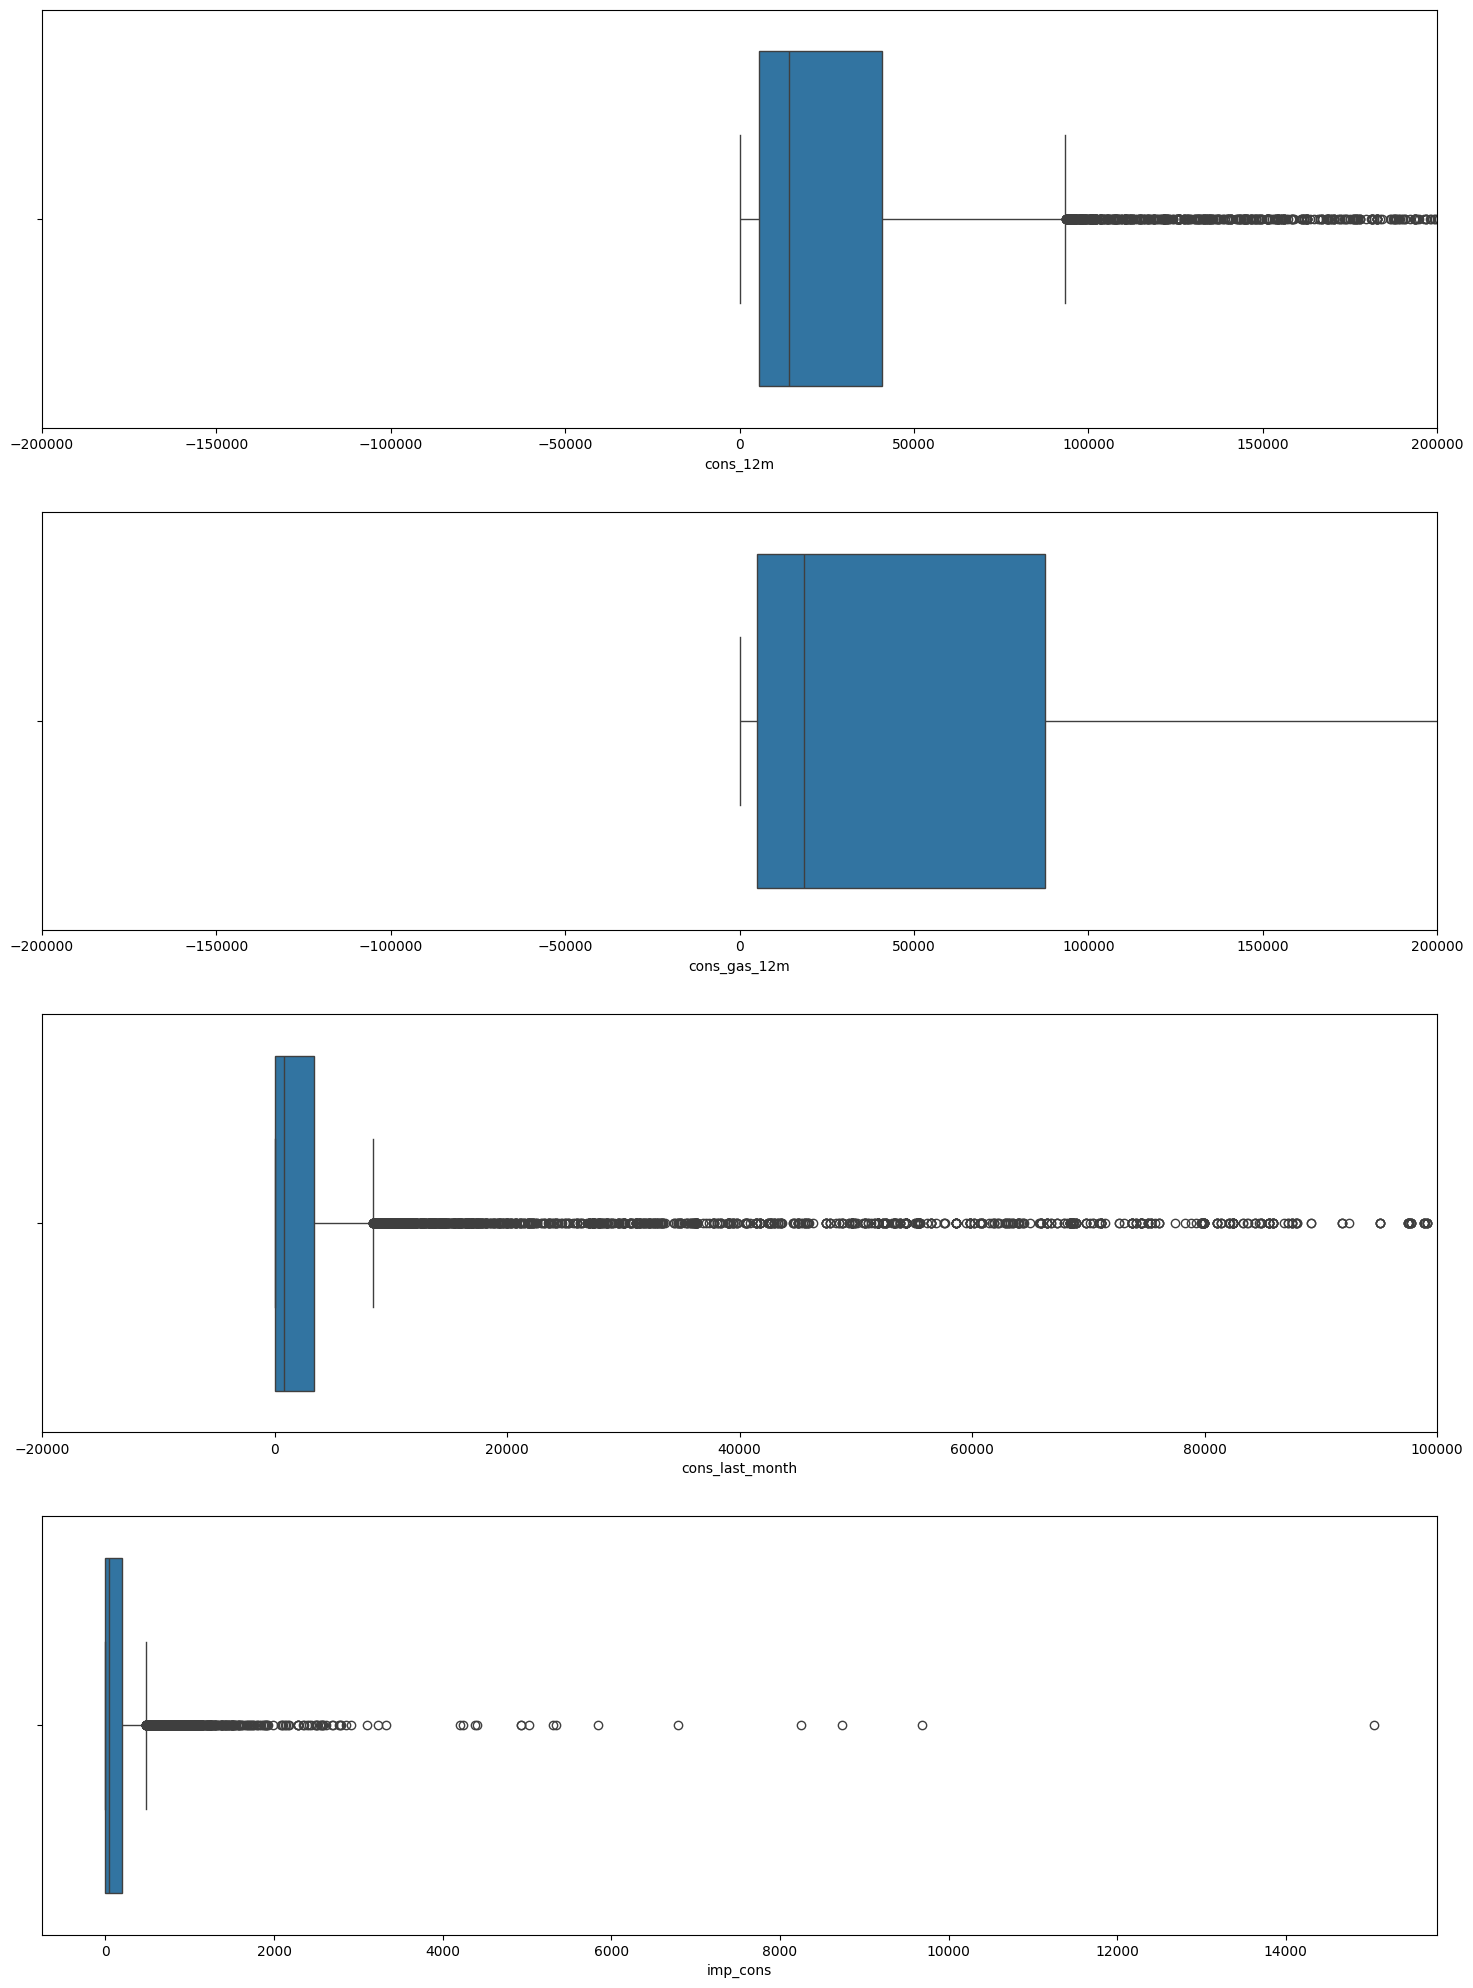

In [ ]:
#Create boxplots to reveal any possible outliers
fig,axs = plt.subplots(nrows=4,figsize=(18,25))

sns.boxplot(x="cons_12m", data=consumption, ax=axs[0])
sns.boxplot(x='cons_gas_12m', data=consumption[consumption["has_gas"]=='t'], ax=axs[1])
sns.boxplot(x='cons_last_month', data=consumption, ax=axs[2])
sns.boxplot(x='imp_cons', data=consumption, ax=axs[3])

#Remove scientific notations
for ax in axs:
  ax.ticklabel_format(style='plain',axis='x')
  #set x-axis limit
  axs[0].set_xlim(-200000,200000)
  axs[1].set_xlim(-200000,200000)
  axs[2].set_xlim(-20000,100000)

plt.show()

Thes outliers will be dealt with in feature engineering part

---



In [ ]:
#Forecast data is univariate , we use histogram to plot their distribution
forecast = client_df[
    ["id", "forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak","churn"
    ]
]

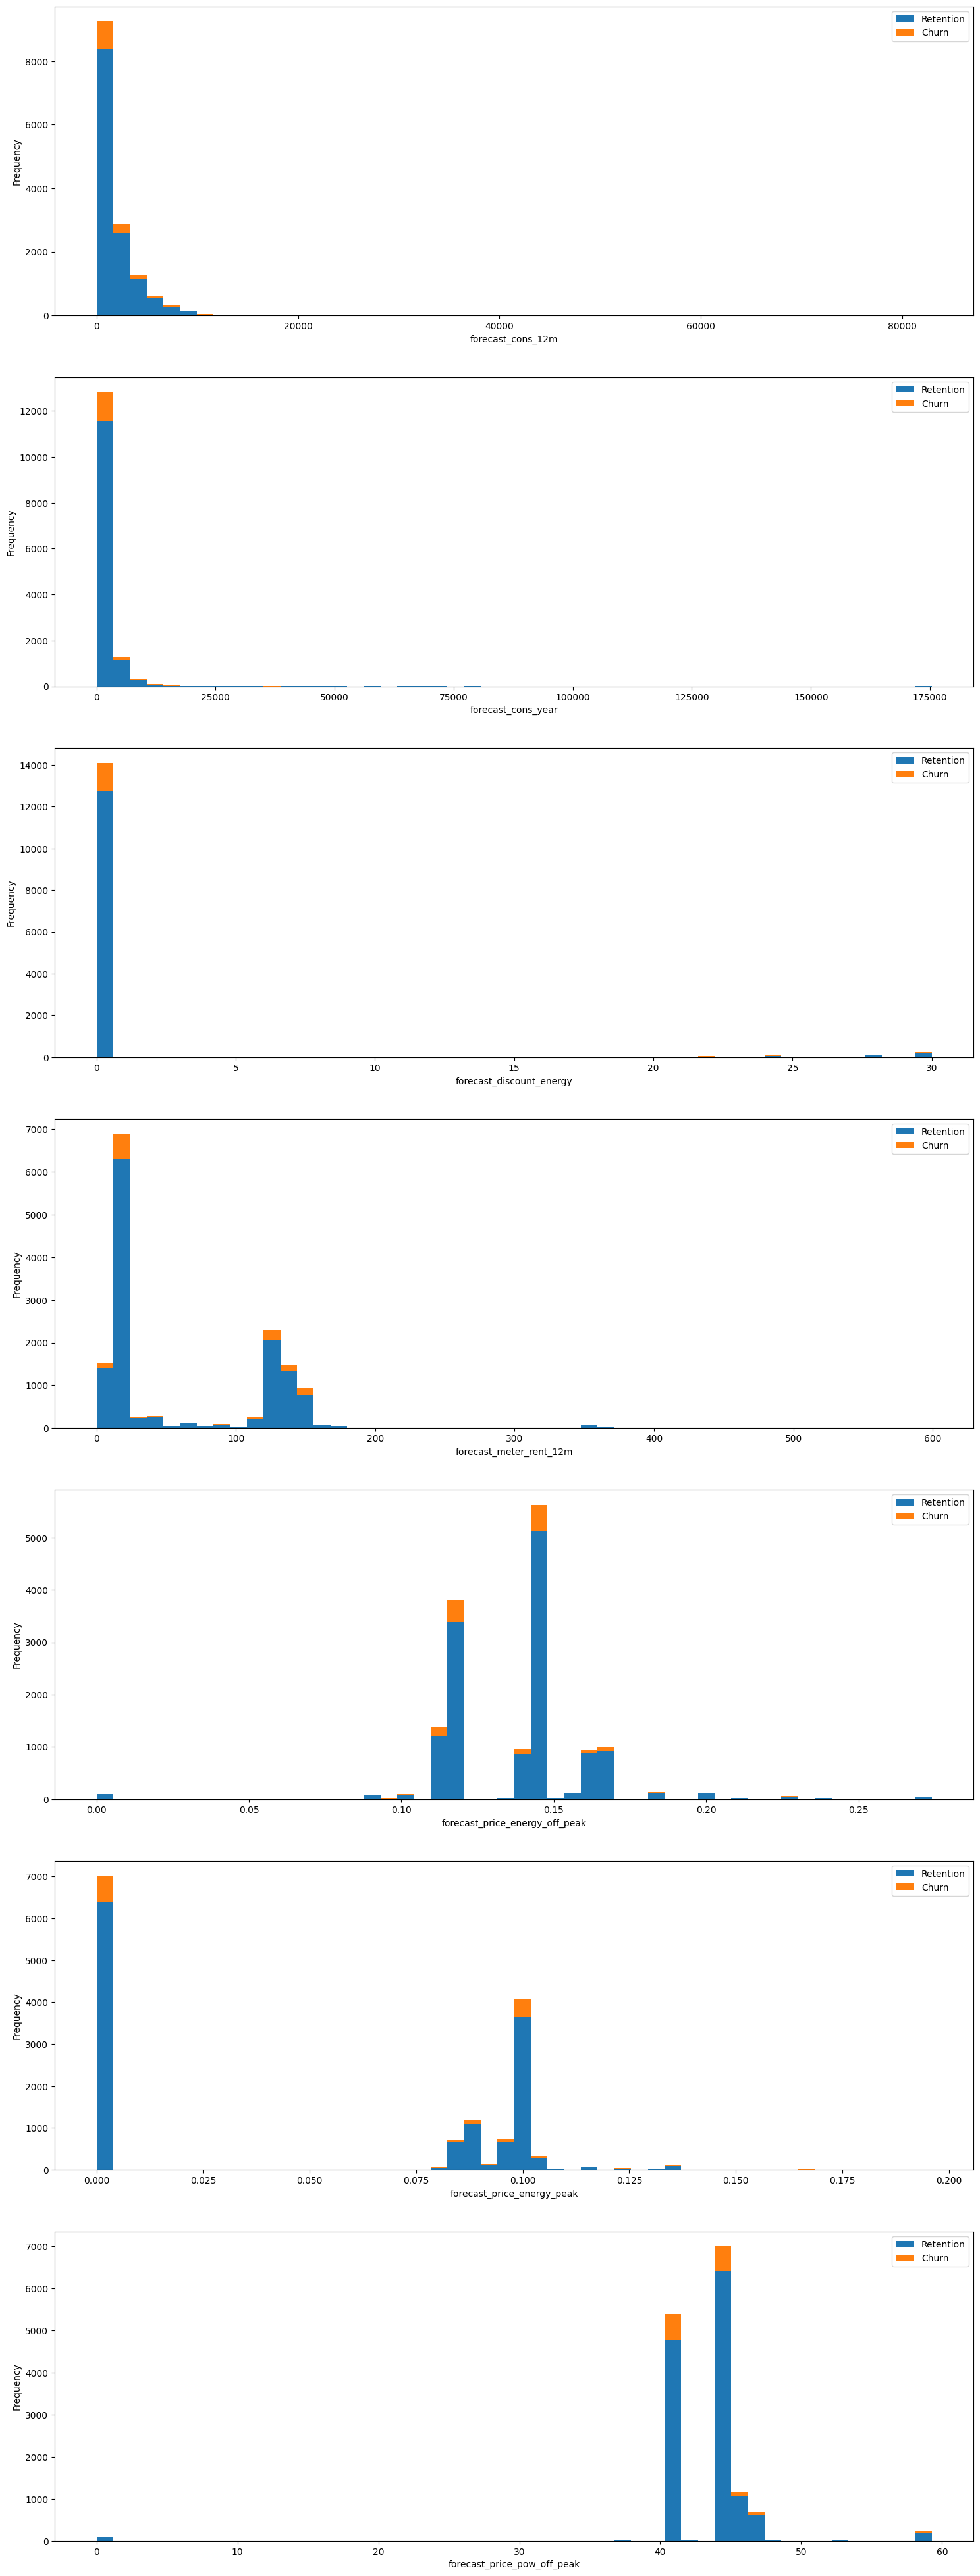

In [ ]:
fig, axs = plt.subplots(nrows=7, figsize=(18,50))

# Plot histogram
plot_distribution(client_df, "forecast_cons_12m", axs[0])
plot_distribution(client_df, "forecast_cons_year", axs[1])
plot_distribution(client_df, "forecast_discount_energy", axs[2])
plot_distribution(client_df, "forecast_meter_rent_12m", axs[3])
plot_distribution(client_df, "forecast_price_energy_off_peak", axs[4])
plot_distribution(client_df, "forecast_price_energy_peak", axs[5])
plot_distribution(client_df, "forecast_price_pow_off_peak", axs[6])

Some portion of the data has skewness, which will be fixed in the feature engineering section

In [ ]:
# Plot stacked bar chart for Contract Type

contract_type = client_df[["id","has_gas","churn"]]
contract = contract_type.groupby([contract_type['churn'],contract_type['has_gas']])['id'].count().unstack(level=0)
contract_percentage = (contract.div(contract.sum(axis=1),axis=0)*100).sort_values(by=[1],ascending=False)

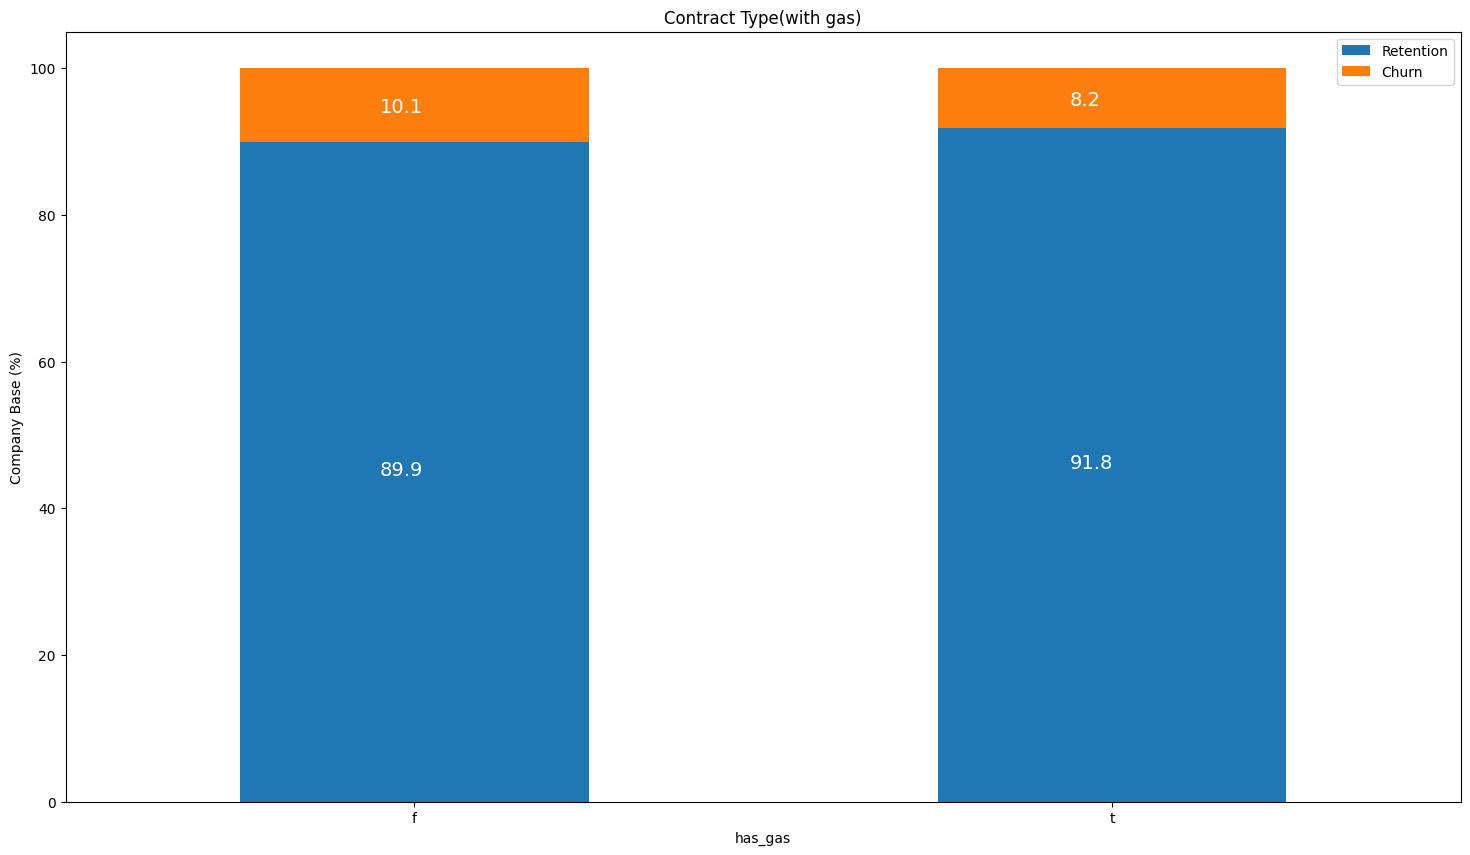

In [ ]:
plot_stacked_bars(contract_percentage,'Contract Type(with gas)')

In [ ]:
#Create boxplots to reveal any possible outliers
margin = client_df[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

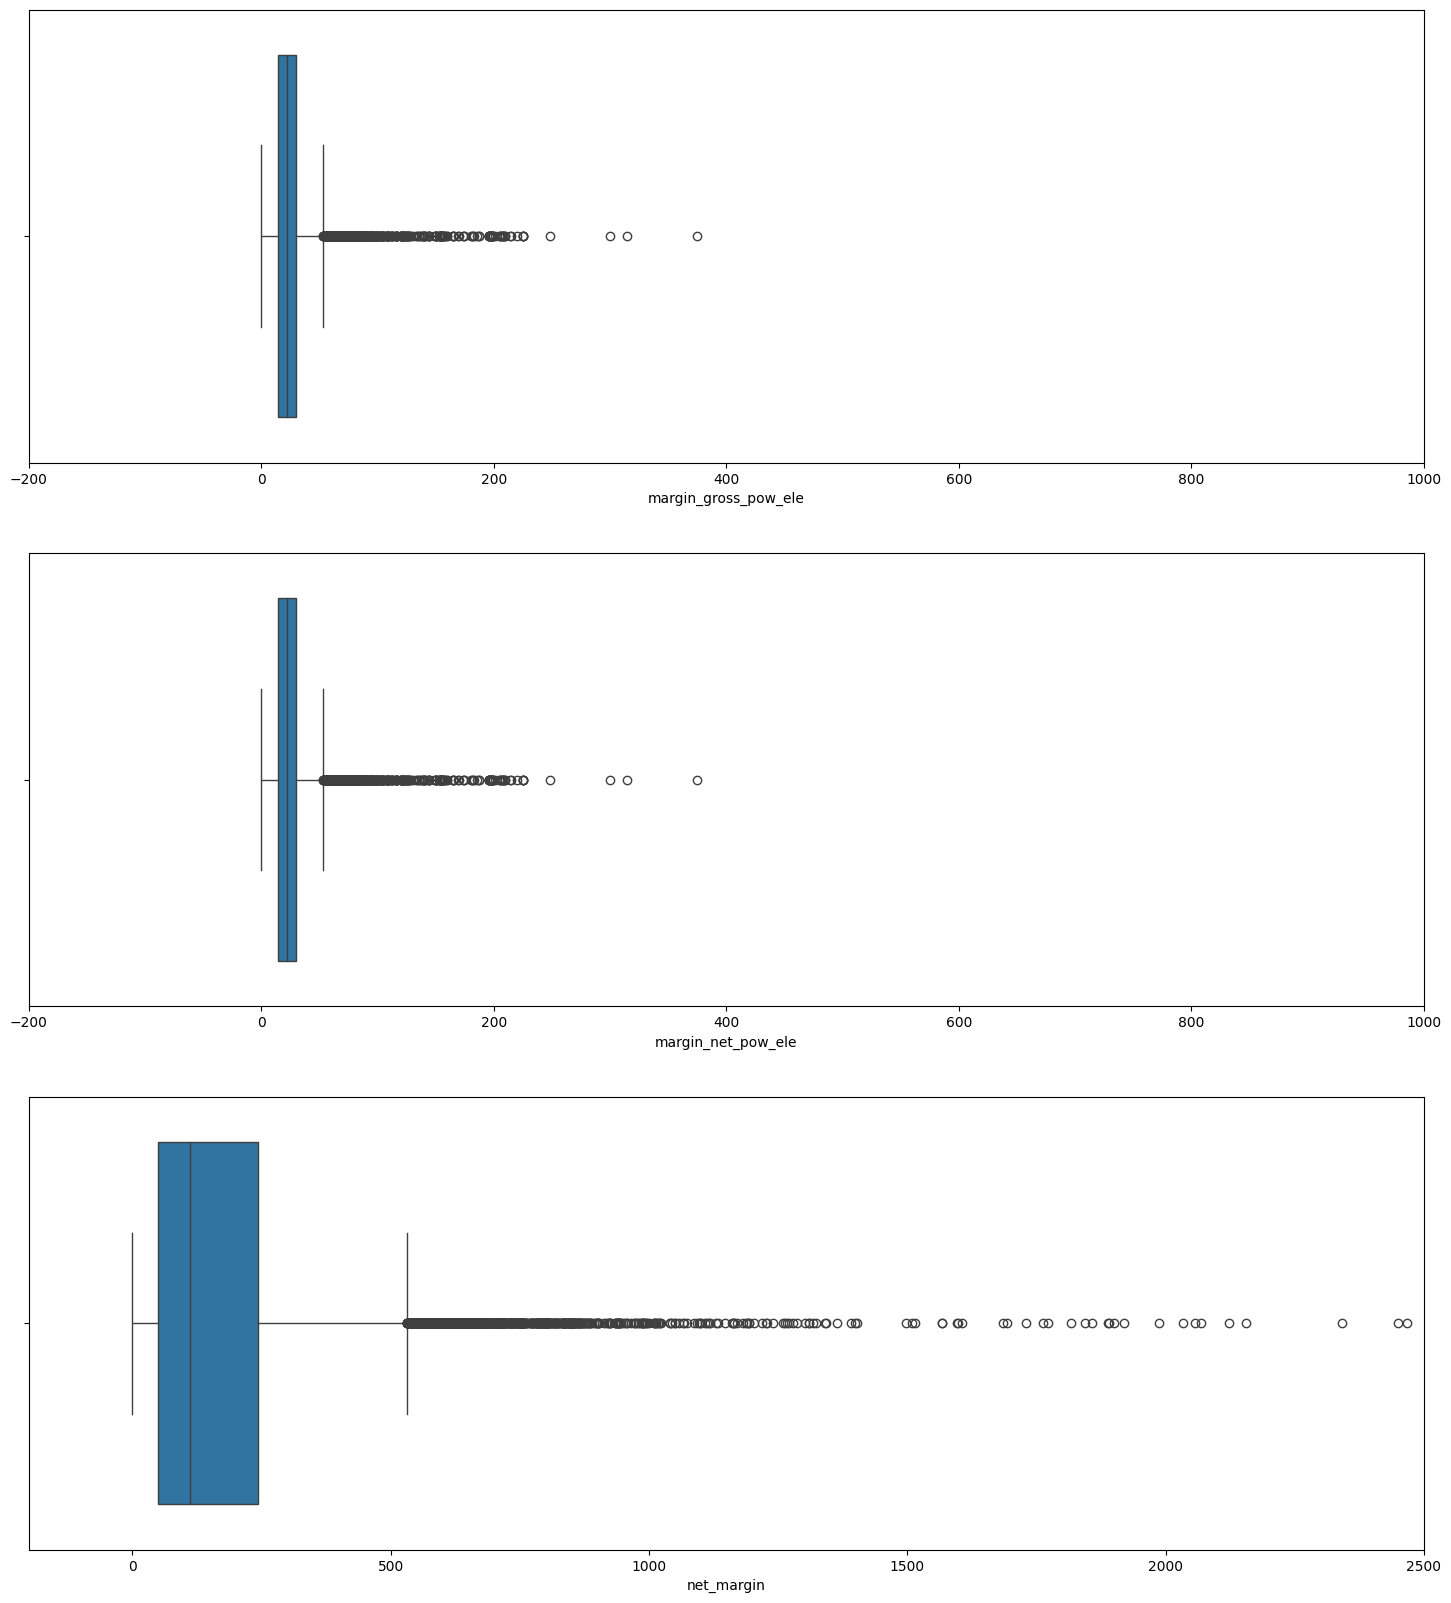

In [ ]:
fig,axs = plt.subplots(nrows=3,figsize=(18,20))

sns.boxplot(x=margin["margin_gross_pow_ele"],ax=axs[0])
sns.boxplot(x=margin["margin_net_pow_ele"],ax=axs[1])
sns.boxplot(x=margin["net_margin"],ax=axs[2])

#Remove scientific notation
for ax in axs:
  ax.ticklabel_format(style='plain',axis='x')

#set x-axis limit
axs[0].set_xlim(-200, 1000)
axs[1].set_xlim(-200, 1000)
axs[2].set_xlim(-200, 2500)

plt.show()

These outliers will also be dealt with later

In [ ]:
#Plot histogram to visualize distribution of Subscribed power
power = client_df[["id","pow_max","churn"]]

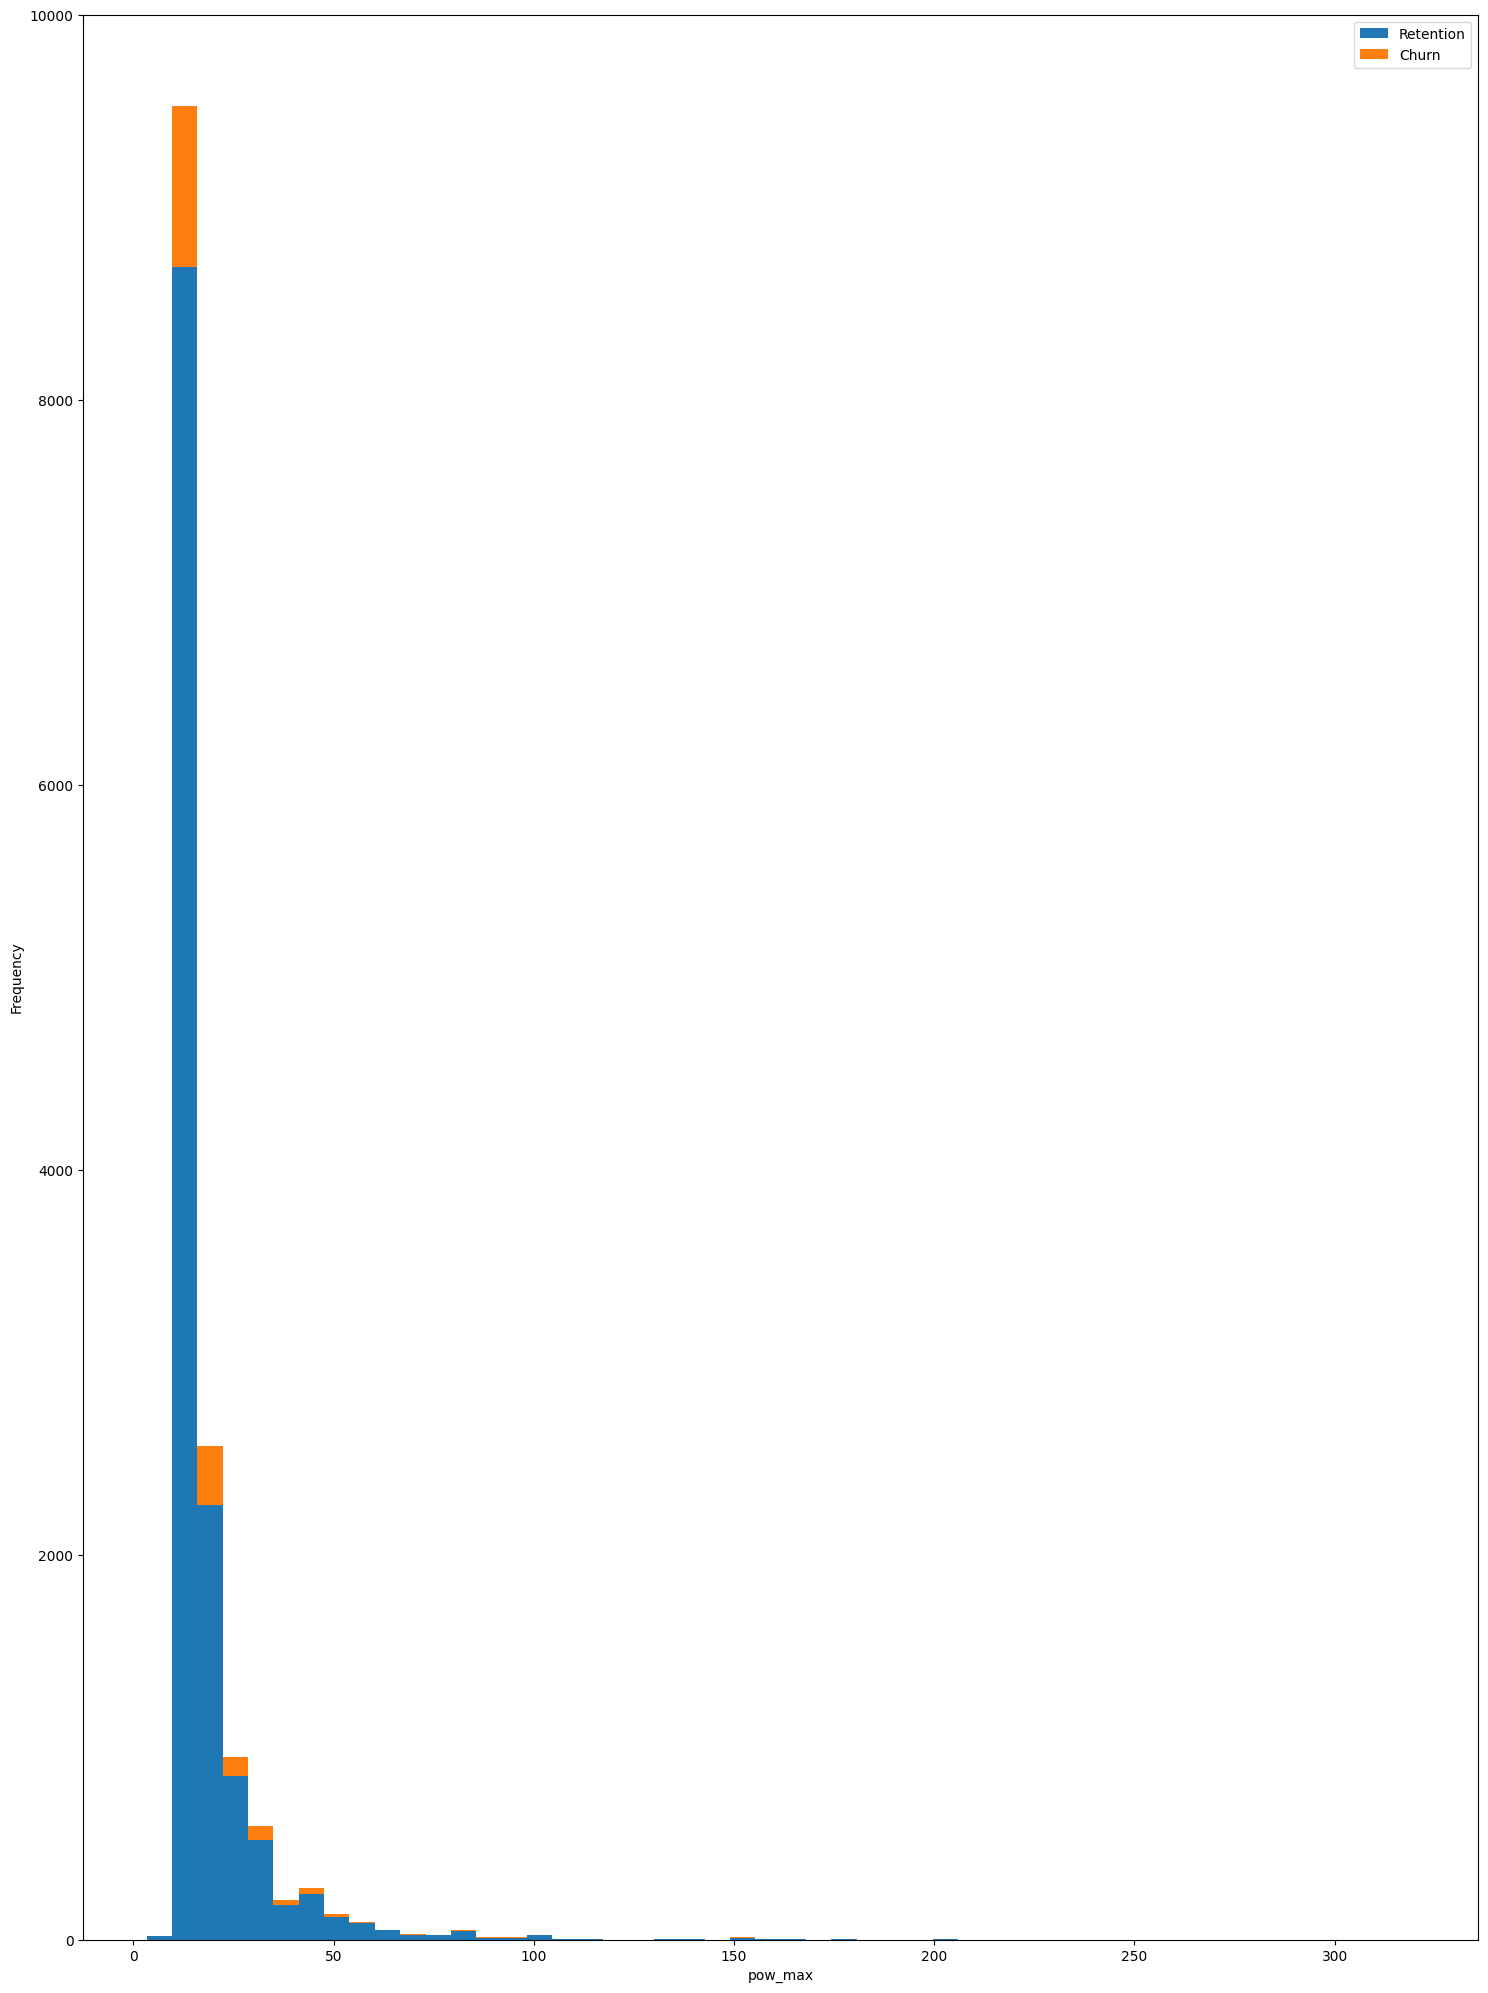

In [ ]:
fig,axs = plt.subplots(nrows=1,figsize=(18,25))
plot_distribution(power,"pow_max",axs)

In [ ]:
#Plotting other columns
others = client_df[['id','num_years_antig','nb_prod_act','origin_up','churn']]

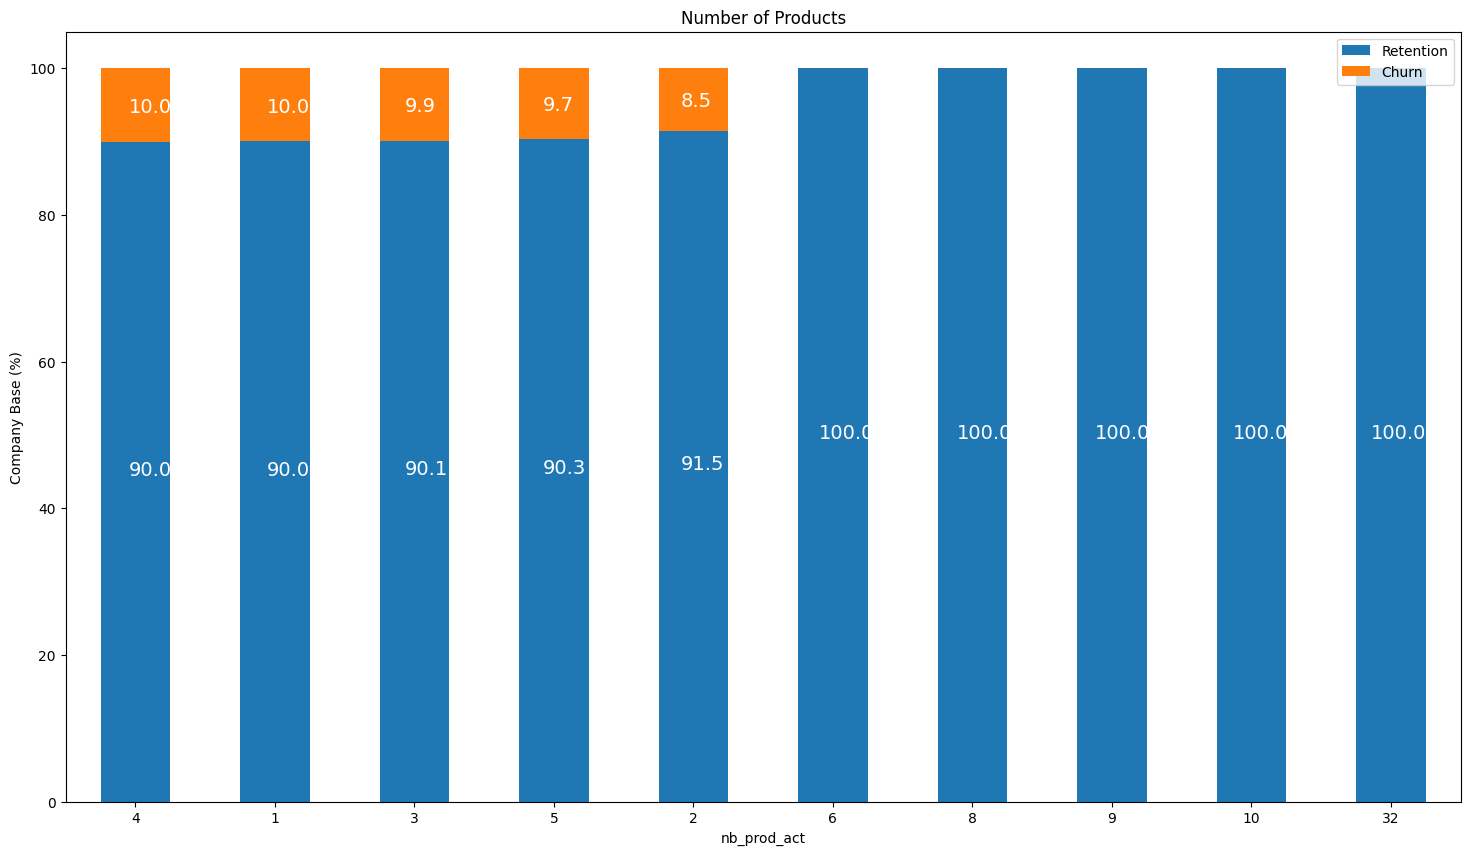

In [ ]:
#Plotting stacked bar charts for products
products = others.groupby([others['nb_prod_act'],others['churn']])['id'].count().unstack(level=1)
product_percentage = (products.div(products.sum(axis=1),axis=0)*100).sort_values(by=[1],ascending=False)
plot_stacked_bars(product_percentage,"Number of Products")

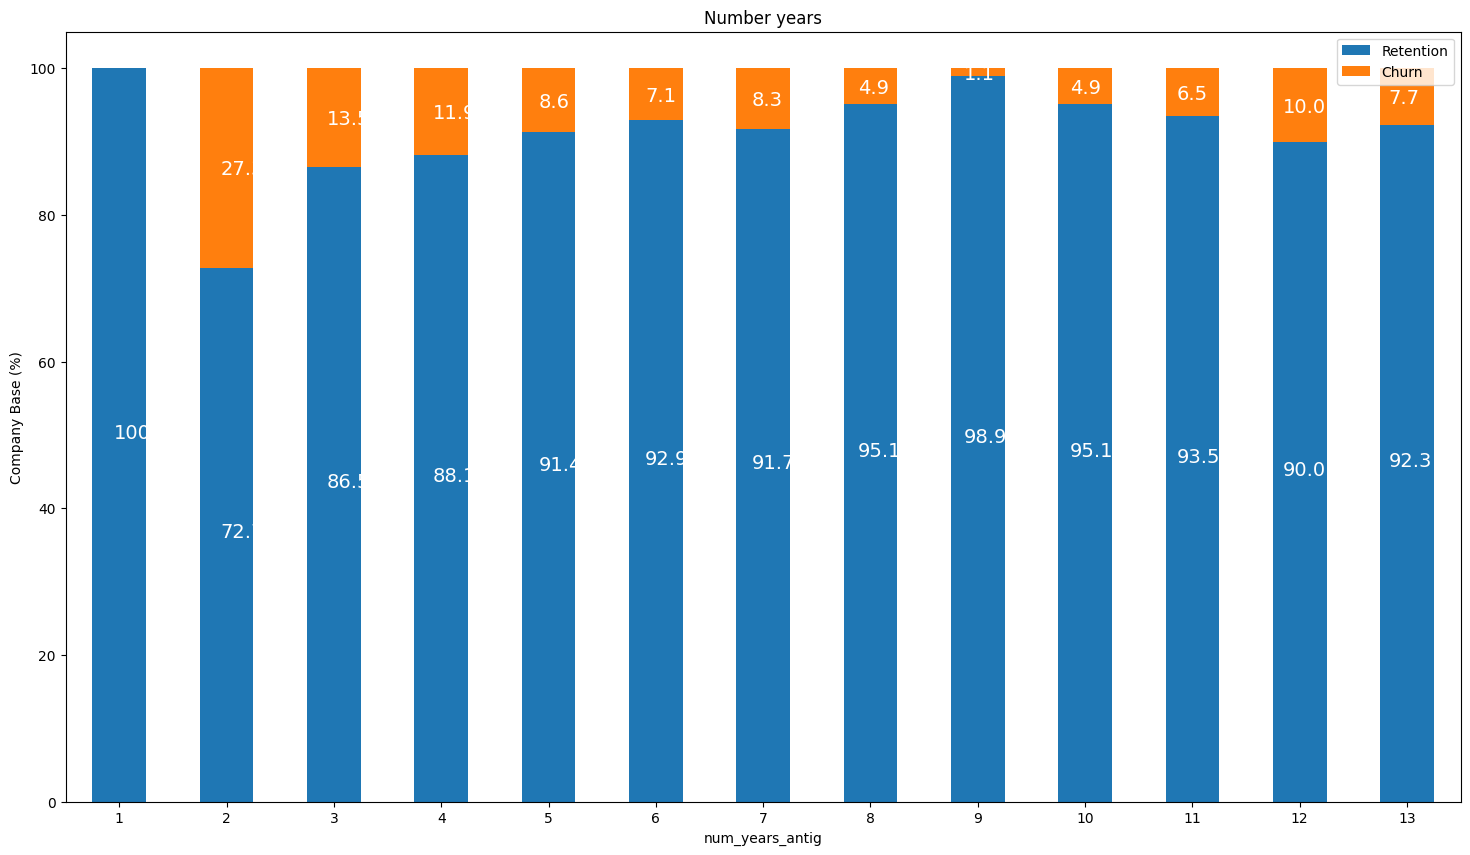

In [ ]:
#Plotting stacked bar charts for number years
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Number years")

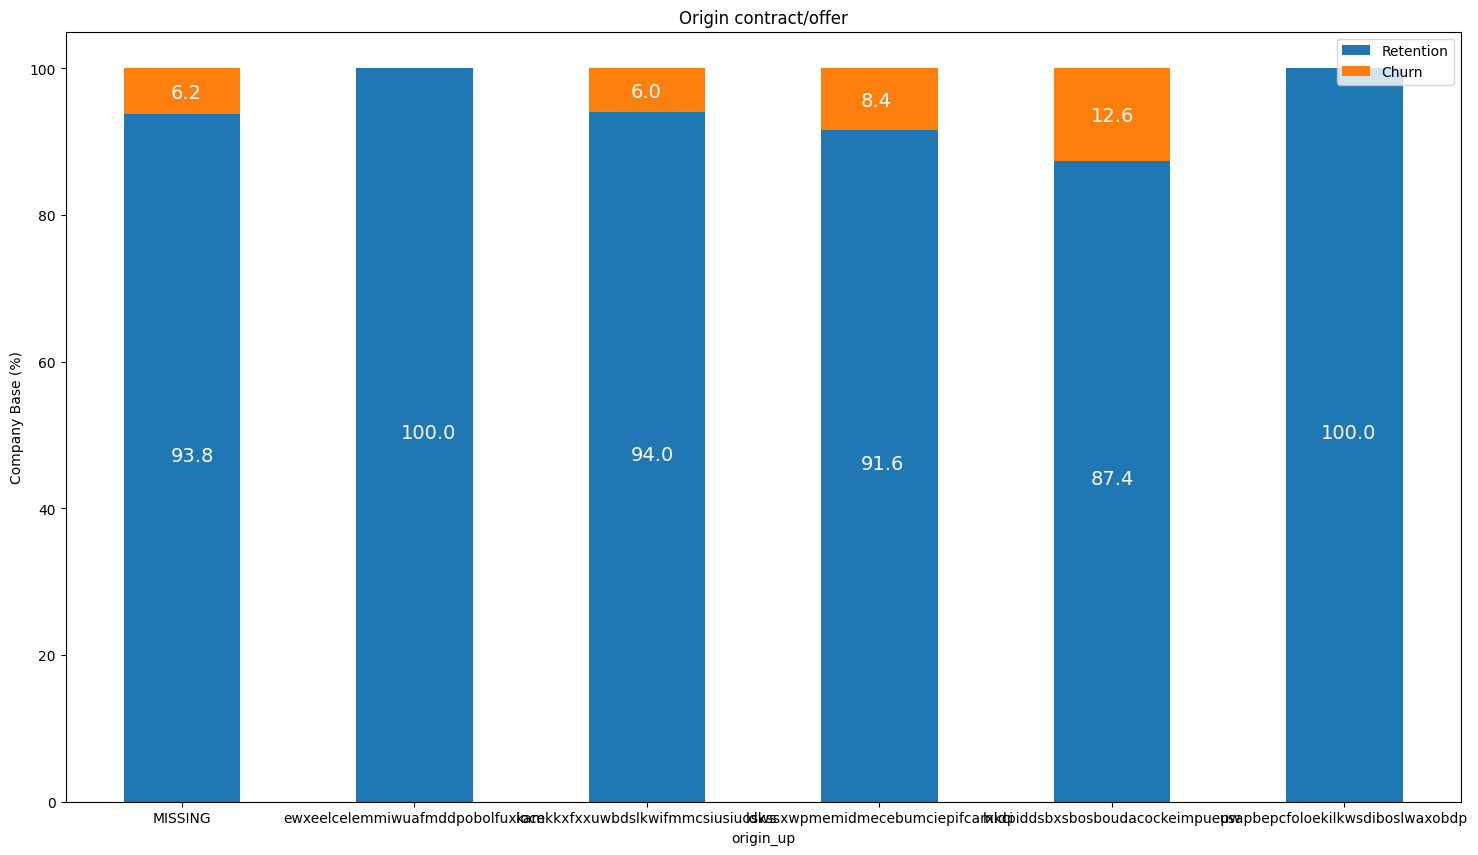

In [ ]:
#Plotting stacked bar charts for products
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer")

In [ ]:
price_df

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
...,...,...,...,...,...,...,...,...
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2015-08-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2015-09-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2015-10-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2015-11-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555


In [ ]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [ ]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


###Analysis Report from EDA

* These visualizations show how many companies churned vs. how many companies did not churn. We can see from this that the churn rate is approximately 10%. This is actually a very good churn rate – the closer the rate is to 0%, the better.
* The next series of visualizations were created in an attempt to dive deeper into how churn changes based on other factors (using other columns). This is useful for us to investigate because it may help us to understand factors that drive churn.
* We've also visualized churn vs. sales channel, contract type, number of products, number of years and origin/contract offer.
* We see that for sales channel, there are some sales channels that yield customers churning but there are also other sales channels that have no customers churning.
* For contract type, we see quite an even split for customers churning. This is interesting because this may suggest that contract type is not a driving factor towards churn rate.
* We notice that the distribution of consumption is very skewed, this is called a positive skew since it is biased towards lower values on the x axis.
* This is interesting because you may decide to transform this column to reduce the skewness later on during feature engineering. In addition, you may want to check for outliers in this column.
* To investigate outliers, we use a boxplot. From the boxplot we can see that with the column as it is there are definitely some outliers. Once again, this is interesting because we may choose to remove some of these outliers later.

###Feature Engineering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/clean_data_after_eda.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [ ]:
#Convert into datetime format
df["date_activ"] = pd.to_datetime(df["date_activ"], format="%Y-%m-%d")
df["date_end"] = pd.to_datetime(df["date_end"], format="%Y-%m-%d")
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format="%Y-%m-%d")
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format="%Y-%m-%d")

In [ ]:
#Import the price data
price_df = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/price_data.csv')
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [ ]:
#convert its date into datetime format
price_df["price_date"] = pd.to_datetime(price_df['price_date'],format='%Y-%m-%d')

In [ ]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [ ]:
df = pd.merge(df,diff,on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,0.020057,3.700961
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,-0.003767,0.177779
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,-0.004670,0.177779
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,-0.004547,0.177779
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,-0.006192,0.162916


Average price changes across periods

Measure of the average price change by company between peak,mid-peak and off-peak periods

In [ ]:
#Aggregate average prices per period by company
mean_prices = price_df.groupby(['id']).agg({
    'price_off_peak_var':'mean',
    'price_peak_var':'mean',
    'price_mid_peak_var':'mean',
    'price_off_peak_fix':'mean',
    'price_peak_fix':'mean',
    'price_mid_peak_fix':'mean'
}).reset_index()

In [ ]:
# Calculate the mean difference between consecutive periods
mean_prices['off_peak_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff'] = mean_prices['price_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff'] = mean_prices['price_peak_fix'] - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

In [ ]:
#Merge the mean prices table with the main df based on id
columns = [
    'id',
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff',
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff',
    'peak_mid_peak_fix_mean_diff',
    'off_peak_mid_peak_fix_mean_diff'
]
df = pd.merge(df, mean_prices[columns], on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,4.423670e+01,1,0.020057,3.700961,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0,-0.003767,0.177779,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0,-0.004670,0.177779,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0,-0.004547,0.177779,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0,-0.006192,0.162916,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893


Instead of looking at differences across an entire year, we have now created features that look at mean average price differences across different time periods (`off_peak`, `peak`, `mid_peak`).

* The dec-jan feature may reveal macro patterns that occur over an entire year,
* whereas inter-time-period features may reveal patterns on a micro scale between months.

Max Price changes across periods and months

Creating another similar feature but instead of looking at the average price difference, we llok at the maximum price difference across periods and months. This gives another way to look at the price changes across months

In [ ]:
# Aggregate average prices per period by company
mean_prices_by_month = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean',
    'price_peak_var': 'mean',
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

In [ ]:
# Calculate the maximum monthly difference across time periods
mean_prices_by_month['off_peak_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_peak_var']
mean_prices_by_month['peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_peak_fix']
mean_prices_by_month['peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']
mean_prices_by_month['off_peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']

max_diff_across_periods_months = mean_prices_by_month.groupby(['id']).agg({
    'off_peak_peak_var_mean_diff': 'max',
    'peak_mid_peak_var_mean_diff': 'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff': 'max',
    'peak_mid_peak_fix_mean_diff': 'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'
}).reset_index().rename(
    columns={
        'off_peak_peak_var_mean_diff': 'off_peak_peak_var_max_monthly_diff',
        'peak_mid_peak_var_mean_diff': 'peak_mid_peak_var_max_monthly_diff',
        'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
        'off_peak_peak_fix_mean_diff': 'off_peak_peak_fix_max_monthly_diff',
        'peak_mid_peak_fix_mean_diff': 'peak_mid_peak_fix_max_monthly_diff',
        'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
    }
)

In [ ]:
columns = [
    'id',
    'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_max_monthly_diff'
]

df = pd.merge(df, max_diff_across_periods_months[columns], on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.058257,18.590255,7.450670,26.040925,0.060550,0.085483,0.146033,44.266930,8.145775,44.26693
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.149609,44.311375,0.000000,44.311375,0.151367,0.085483,0.151367,44.444710,0.000000,44.44471
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.170512,44.385450,0.000000,44.385450,0.084587,0.089162,0.172468,44.444710,0.000000,44.44471
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.151210,44.400265,0.000000,44.400265,0.153133,0.000000,0.153133,44.444710,0.000000,44.44471
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.051309,16.275263,8.137629,24.412893,0.022225,0.033743,0.055866,16.291555,8.145775,24.43733


Reason why these 2 features can be useful is because they are another way of representing the variance of prices throughout the year.

Imagine your utilities bill suddenly increased over winter, as a consumer you'd be annoyed and want to find a better deal!

Further Feature Engieering

In [ ]:
#Calculate Tenure = how long a company has been a client of PowerCo
df['tenure'] = ((df['date_end'] - df['date_activ']).dt.days / 365.25).astype(int)

In [ ]:
df.groupby(['tenure']).agg({'churn':'mean'}).sort_values(by='churn',ascending=False)

,churn
tenure,
3,0.143713
2,0.133080
4,0.125756
13,0.095238
5,0.085425
12,0.083333
6,0.080713
7,0.073394
11,0.063584


Observe that, companies who have been client for **4 months or less** are **more likely to churn** compared to companies that have been client for longer periods.

Interestingly, the **difference between 4 and 5 months is about 4%**, which represents a large jump in likelihood for a customer to churn compared to the other differences in ordered tenure values.

i.e. Getting a customer to stay for more than 4 months --> a large milestone for keeping them as long-term customer

Transform dates into months

To make predictions with a statistical or machine learning algorithm, all of the data must be converted to numeric data types.
Therefore, we convert date into months and remove the raw date column, as we cannot use it in its original form.

* months_activ =  no. of months active until reference date(Jan 2016)
* months_to_end = no. of months of contract left until reference date(Jan 2016)
* months_modif_prod = no. of months since last modification until reference date(Jan 2016)
* months_renewal = no. of months since last renewal until reference date(Jan 2016)

In [ ]:
#Create a function that converts date into months
def convert_months(reference_date,df,column):
  time_delta = reference_date - df[column]
  months = (time_delta.dt.days / 30.44).astype(int) # Divide by average days in a month
  return months

In [ ]:
#Create reference date
reference_date = pd.Timestamp(2016,1,1)

#Create columns
df['months_activ'] = convert_months(reference_date,df,'date_activ')
df['months_to_end'] = -convert_months(reference_date,df,'date_end')
df['months_modif_prod'] = convert_months(reference_date,df,'date_modif_prod')
df['months_renewal'] = convert_months(reference_date,df,'date_renewal')

Dates as a datetime object are not useful for a predictive model, so we needed to use the datetimes to create some other features that may hold some predictive power.

Using intuition, you could assume that a client who has been an active client of PowerCo for a longer amount of time may have more loyalty to the brand and is more likely to stay. Whereas a newer client may be more volatile. Hence the addition of the `months_activ` feature.

As well as this, if we think from the perspective of a client with PowerCo, if you're coming toward the end of your contract with PowerCo your thoughts could go a few ways. You could be looking for better deals for when your contract ends, or you might want to see out your contract and sign another one. One the other hand if you've only just joined, you may have a period where you're allowed to leave if you're not satisfied. Furthermore, if you're in the middle of your contract, their may be charges if you wanted to leave, deterring clients from churning mid-way through their agreement. So, I think `months_to_end` will be an interesting feature because it may reveal patterns and behaviours about timing of churn.

My belief is that if a client has made recent updates to their contract, they are more likely to be satisfied or at least they have received a level of customer service to update or change their existing services. I believe this to be a positive sign, they are an engaged customer, and so I believe `months_modif_prod` will be an interesting feature to include because it shows the degree of how 'engaged' a client is with PowerCo.

Finally the number of months since a client last renewed a contract I believe will be an interesting feature because once again, it shows the degree to which that client is engaged. It also goes a step further than just engagement, it shows a level of commitment if a client renews their contract. For this reason, I believe `months_renewal` will be a good feature to include.

In [ ]:
#Drop the unnecessary datetime columns
remove =['date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal']

df = df.drop(columns=remove)

Transforming Boolean data

Simply want to transform the column `has_gas` from being categorical to a binary flag

In [ ]:
#Converting boolean columns into binary values
df['has_gas'] = df['has_gas'].replace(['t','f'],[1,0])
df.groupby(['has_gas']).agg({'churn':'mean'})

/tmp/ipython-input-1942414148.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_gas'] = df['has_gas'].replace(['t','f'],[1,0])


,churn
has_gas,
0,0.100544
1,0.081856


If a customer also buys gas from PowerCo, it shows that they have multiple products and are a loyal customer to the brand.

Customers who **do not buy gas** are **2% more likely to churn** than customers who also buy gas from PowerCo

Transforming Categorical variables


The simplest method is to map each category to an integer (label encoding), however this is not always appropriate beecause it then introduces the concept of an order into a feature which may not inherently be present `0 < 1 < 2 < 3 ...`

Another way to encode categorical features is to use `dummy variables` AKA `one hot encoding`. This create a new feature for every unique value of a categorical column, and fills this column with either a 1 or a 0 to indicate that this company does or does not belong to this category

In [ ]:
#Transforming the channel_sales column
df['channel_sales'] = df['channel_sales'].astype('category')
df['channel_sales'].value_counts()

,count
channel_sales,
foosdfpfkusacimwkcsosbicdxkicaua,6754
MISSING,3725
lmkebamcaaclubfxadlmueccxoimlema,1843
usilxuppasemubllopkaafesmlibmsdf,1375
ewpakwlliwisiwduibdlfmalxowmwpci,893
sddiedcslfslkckwlfkdpoeeailfpeds,11
epumfxlbckeskwekxbiuasklxalciiuu,3
fixdbufsefwooaasfcxdxadsiekoceaa,2


We have 8 categories, so we will create 8 dummy variables from this column. However, as you can see the last 3 categories in the output above, show that they only have 11, 3 and 2 occurrences respectively. Considering that our dataset has about 14000 rows, this means that these dummy variables will be almost entirely 0 and so will not add much predictive power to the model at all (since they're almost entirely a constant value and provide very little).

For this reason, we will drop these 3 dummy variables.

In [ ]:
df = pd.get_dummies(df,columns=['channel_sales'],prefix = 'channel')
df = df.drop(columns=['channel_sddiedcslfslkckwlfkdpoeeailfpeds', 'channel_epumfxlbckeskwekxbiuasklxalciiuu', 'channel_fixdbufsefwooaasfcxdxadsiekoceaa'])

In [ ]:
#Transforming the origin_up column
df['origin_up'] = df['origin_up'].astype('category')
df['origin_up'].value_counts()

,count
origin_up,
lxidpiddsbxsbosboudacockeimpuepw,7097
kamkkxfxxuwbdslkwifmmcsiusiuosws,4294
ldkssxwpmemidmecebumciepifcamkci,3148
MISSING,64
usapbepcfoloekilkwsdiboslwaxobdp,2
ewxeelcelemmiwuafmddpobolfuxioce,1


Similar to `channel_sales` the last 3 categories in the output above show very low frequency, so we will remove these from the features after creating dummy variables.

In [ ]:
df = pd.get_dummies(df,columns=['origin_up'],prefix='origin_up')
df = df.drop(columns=['origin_up_MISSING', 'origin_up_usapbepcfoloekilkwsdiboslwaxobdp', 'origin_up_ewxeelcelemmiwuafmddpobolfuxioce'])

Transforming Numerical Data

### Transforming numerical data

In the previous exercise we saw that some variables were highly skewed. The reason why we need to treat skewness is because some predictive models have inherent assumptions about the distribution of the features that are being supplied to it. Such models are called `parametric` models, and they typically assume that all variables are both independent and normally distributed.

Skewness isn't always a bad thing, but as a rule of thumb it is always good practice to treat highly skewed variables because of the reason stated above, but also as it can improve the speed at which predictive models are able to converge to its best solution.

There are many ways that you can treat skewed variables. You can apply transformations such as:
- Square root
- Cubic root
- Logarithm

to a continuous numeric column and you will notice the distribution changes. For this use case we will use the 'Logarithm' transformation for the positively skewed features.

<b>Note:</b> We cannot apply log to a value of 0, so we will add a constant of 1 to all the values

In [ ]:
#see the statistics of the skewed features, so that we can compare before and after transformation
skewed = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'forecast_cons_12m',
    'forecast_cons_year',
    'forecast_discount_energy',
    'forecast_meter_rent_12m',
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak',
    'forecast_price_pow_off_peak'
]

df[skewed].describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378


See that standard deviation of most features are quite high

In [ ]:
#Apply log10 transformation
df['cons_12m'] = np.log10(df['cons_12m'] + 1)
df["cons_gas_12m"] = np.log10(df["cons_gas_12m"] + 1)
df["cons_last_month"] = np.log10(df["cons_last_month"] + 1)
df["forecast_cons_12m"] = np.log10(df["forecast_cons_12m"] + 1)
df["forecast_cons_year"] = np.log10(df["forecast_cons_year"] + 1)
df["forecast_meter_rent_12m"] = np.log10(df["forecast_meter_rent_12m"] + 1)
df["imp_cons"] = np.log10(df["imp_cons"] + 1)

In [ ]:
df[skewed].describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak
count,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,4.223939,0.779244,2.264646,2.962177,1.784610,0.966726,1.517203,0.137283,0.050491,43.130056
std,0.884515,1.717071,1.769305,0.683592,1.584986,5.108289,0.571481,0.024623,0.049037,4.485988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.754023,0.000000,0.000000,2.695477,0.000000,0.000000,1.235023,0.116340,0.000000,40.606701
50%,4.149727,0.000000,2.899547,3.046836,2.498311,0.000000,1.296555,0.143166,0.084138,44.311378
75%,4.610285,0.000000,3.529430,3.380716,3.242231,0.000000,2.120673,0.146348,0.098837,44.311378
max,6.792889,6.618528,5.887169,4.918575,5.243970,30.000000,2.778376,0.273963,0.195975,59.266378


Now we can see that for the majority of the features, their standard deviation is much lower after transformation. This is a good thing, it shows that these features are more stable and predictable now.

Let's quickly check the distributions of some of these features too.

/tmp/ipython-input-3336105285.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((df["cons_12m"].dropna()), ax=axs[0])
/tmp/ipython-input-3336105285.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((df[df["has_gas"]==1]["cons_gas_12m"].dropna()), ax=axs[1])
/tmp/ipython-input-3336105285.py:5

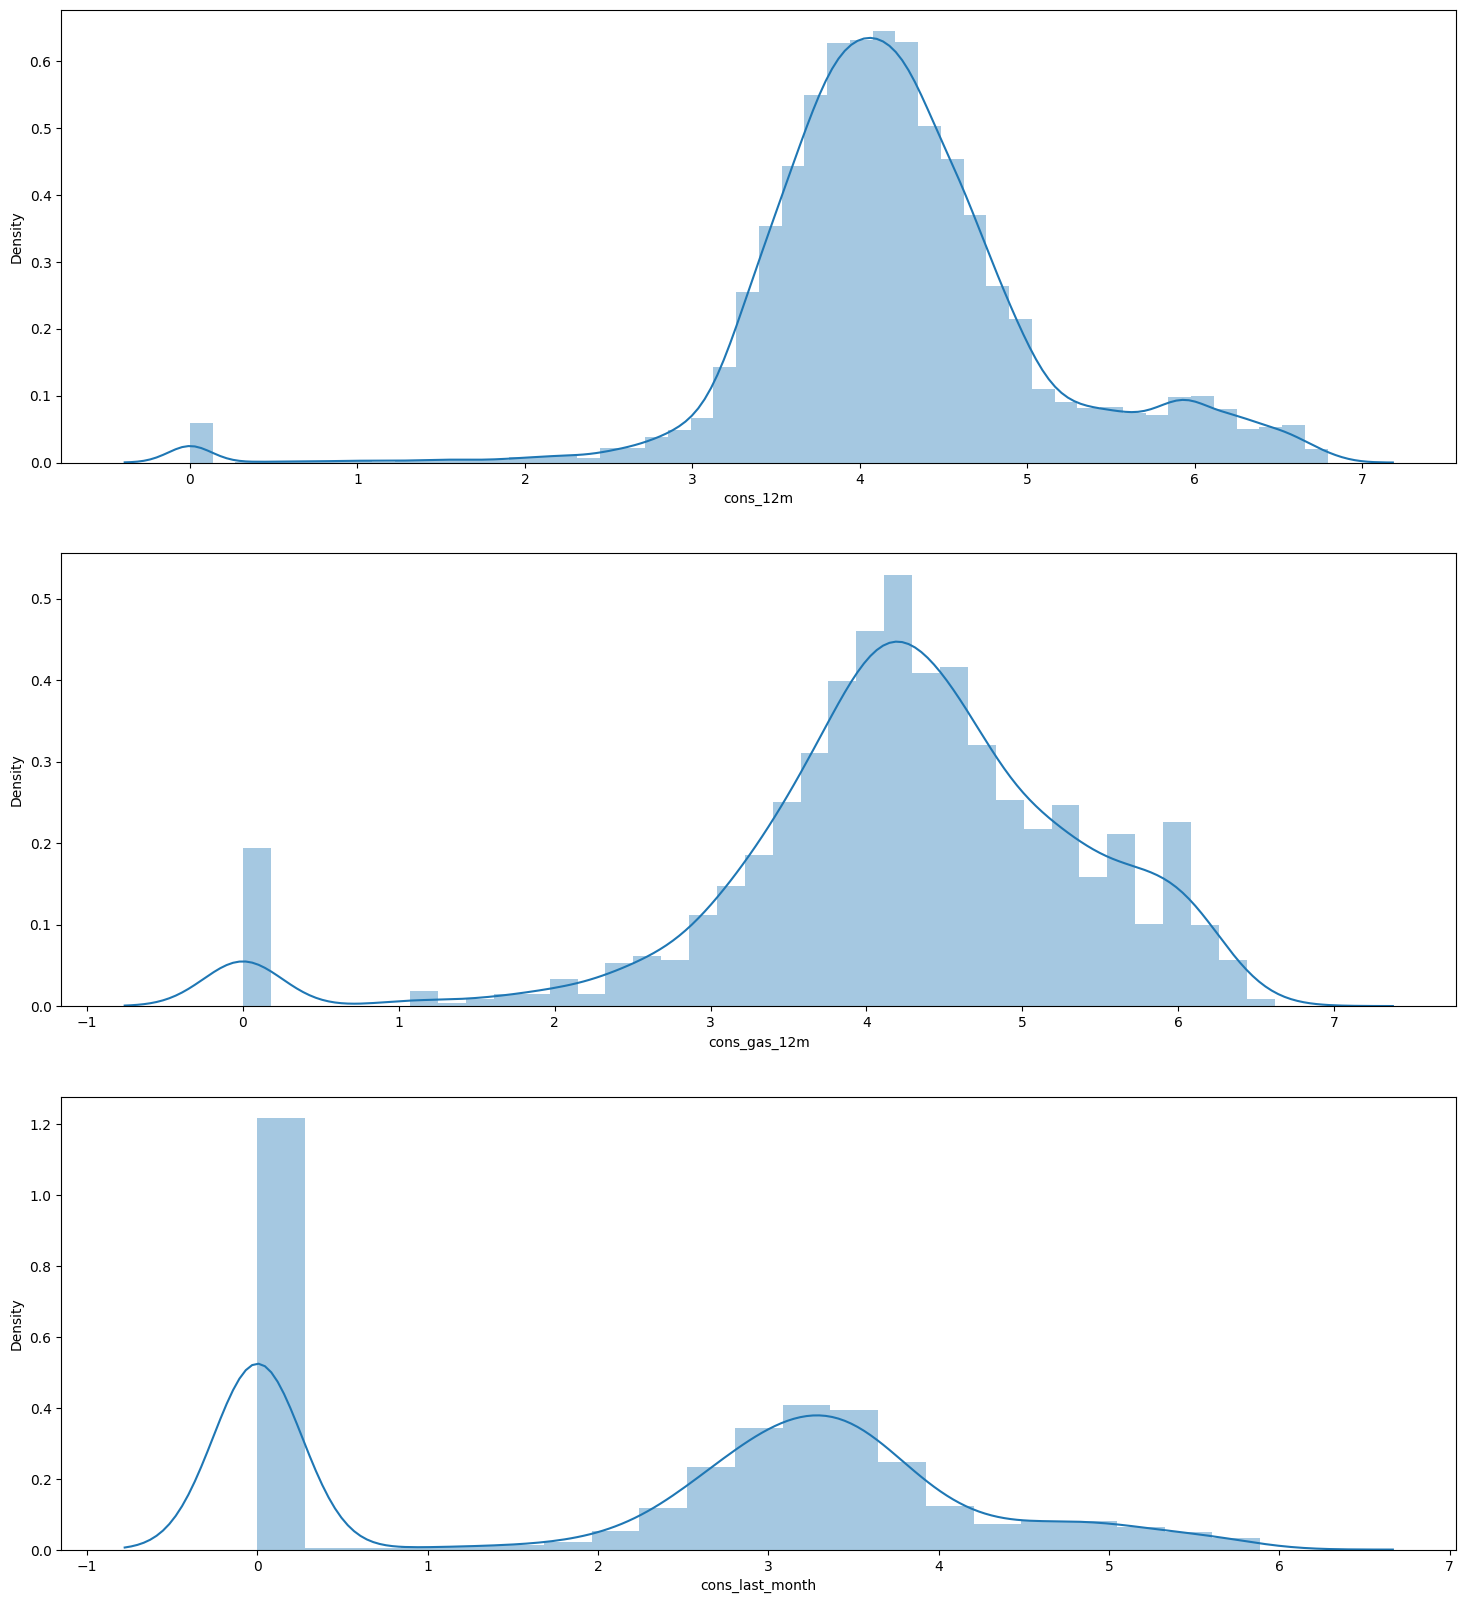

In [ ]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 20))
# Plot histograms
sns.distplot((df["cons_12m"].dropna()), ax=axs[0])
sns.distplot((df[df["has_gas"]==1]["cons_gas_12m"].dropna()), ax=axs[1])
sns.distplot((df["cons_last_month"].dropna()), ax=axs[2])
plt.show()

One common assumption is that the columns within the data are normally distributed. Hence, if we find that columns are not normally distributed, we should treat these columns to try and transform them into a distribution that is more normal.


Therefore, the next thing we do is transform some columns to have a closer to normal distribution. We do this using the logarithm function. As you can see from the visualisations, the newly transformed columns are much closer to a normal distribution than what they were earlier.

Correlations

Finally, we plot correlations of all the columns to see if we can identify any columns to remove. Columns that have very high correlations indicate an area to look out for. In this case, you may want to remove one of the columns, since they are likely both holding very similar information.

In [ ]:
correlation = df.drop(columns=['id']).corr()

# Plot correlation
plt.figure(figsize=(45, 45))
sns.heatmap(
    correlation,
    xticklabels=correlation.columns.values,
    yticklabels=correlation.columns.values,
    annot=True,
    annot_kws={'size': 12}
)
# Axis ticks size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Ideally, you want a set of features that have 0 correlation with all of the independent variables (all features except our target variable) and a high correlation with the target variable (churn). However, this is very rarely the case and it is common to have a small degree of correlation between independent features.

Removing two columns which exhibit a high correlation with other independent features

In [ ]:
df = df.drop(columns=['num_years_antig', 'forecast_cons_year'])
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,False,False,True,False,False,False,False,True
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,True,False,False,False,False,True,False,False
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,False,False,True,False,False,True,False,False
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,False,False,False,True,False,True,False,False
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,True,False,False,False,False,True,False,False


###Summarizing what we've done in Feature Engineering

* First, we have the average price changes across periods. This is a measure of the average price change by company between peak, mid-peak and off peak periods.
* We then take this idea one step further by creating another similar feature but instead of looking at the average price difference, we look at the maximum price difference across periods and months. This gives another way to look at the price changes across months.
* The reason why these 2 features could be useful is because they are another way of representing the variance of prices throughout the year. Imagine, if your utilities bill massively increased over winter, as a consumer you’d be annoyed and want to find a better deal!
* After this we continue feature engineering with some more concepts, including transformation of columns.
* To make predictions with a statistical or machine learning algorithm, all of the data must be converted to numeric data types.
* Therefore, we convert date into months and remove the raw date column, as we cannot use it in its original form.
* We also convert boolean columns into binary values.
* And we convert categorical columns into dummy variables. A dummy variable is a binary flag that indicates when a row matches the value from the categorical column that it was created from.

As we saw during exploratory data analysis, the distribution of some columns was skewed. This is important to identify because when modeling data for prediction, based on the technique or algorithm that we use, there are sometimes assumptions within the data that we should follow.

* One common assumption is that the columns within the data are normally distributed. Hence, if we find that columns are not normally distributed, we should treat these columns to try and transform them into a distribution that is more normal.

Therefore, the next thing we do is transform some columns to have a closer to normal distribution. We do this using the logarithm function. As you can see from the visualizations, the newly transformed columns are much closer to a normal distribution than they were earlier.

Finally, we plot correlations of all the columns to see if we can identify any columns to remove. Columns that have very high correlations indicate an area to look out for. In this case, you may want to remove one of the columns, since they are likely both holding very similar information.

###Modelling & Evaluation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/data_for_predictions.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 64 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  14606 non-null  int64  
 1   id                                          14606 non-null  object 
 2   cons_12m                                    14606 non-null  float64
 3   cons_gas_12m                                14606 non-null  float64
 4   cons_last_month                             14606 non-null  float64
 5   forecast_cons_12m                           14606 non-null  float64
 6   forecast_discount_energy                    14606 non-null  float64
 7   forecast_meter_rent_12m                     14606 non-null  float64
 8   forecast_price_energy_off_peak              14606 non-null  float64
 9   forecast_price_energy_peak                  14606 non-null  float64
 10  forecast_p

In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
#Separate target variables from independent variables
X = df.drop(columns=['id','churn'])
y = df['churn']

Data Sampling

Split our given dataset into train-validation-test sets in the ratio of 7:2:1

* Training  = 70%
* Validation  = 20%
* Test  = 10%

In [ ]:
#Splitting Dataset
X_temp,X_test,y_temp,y_test = train_test_split(X,y,test_size=0.1,random_state=42)
X_train,X_valid,y_train,y_valid = train_test_split(X_temp,y_temp,test_size=(0.2/0.9),random_state=42)

Model Training

Once again, we are using a `Random Forest` classifier in this example.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

Using Cross Validation to determine the best parameters that facilitate model training.

**RandomizedSearchCV** --> For larger hyperparameter space

* n_estimators ranges from 10 to 1000 i.e. random forest wll consist of decision trees from 100 to 1000
* max_features ranges from 1 to 10
* no. of iterations = 10
* validation sets = 5


In [ ]:
model = RandomForestClassifier(random_state=42)

param_distrib = {
    'n_estimators':randint(10,100),
    'max_features':randint(2,8)
}

random_search = RandomizedSearchCV(model,param_distributions=param_distrib,n_iter=10,cv=5,random_state=42)
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79e1377d46b0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79e1311989e0>},
                   random_state=42)

In [ ]:
#Choosing the final model as best estimator for the final model
final_model = random_search.best_estimator_
final_model.feature_importances_

array([0.04775912, 0.01072618, 0.03496851, 0.04502694, 0.00147426,
       0.04775319, 0.02201015, 0.01149269, 0.00481089, 0.00481758,
       0.03028867, 0.04358335, 0.04722004, 0.00862385, 0.04700759,
       0.03422618, 0.02882383, 0.01535678, 0.01260349, 0.01999368,
       0.00596328, 0.00590915, 0.03001942, 0.01542591, 0.01258998,
       0.01913346, 0.00970804, 0.0071376 , 0.00717524, 0.0024439 ,
       0.00241992, 0.01840638, 0.00966097, 0.00595484, 0.02363467,
       0.00723672, 0.02740194, 0.0132793 , 0.02632086, 0.01402375,
       0.00554922, 0.01359283, 0.01519749, 0.00856665, 0.01629045,
       0.00499671, 0.00149044, 0.00473658, 0.01768132, 0.03090411,
       0.01498545, 0.02773099, 0.01582721, 0.0048774 , 0.00289935,
       0.00734248, 0.00344295, 0.00429774, 0.00500574, 0.0041492 ,
       0.00802343])

 Evaluation

Now let's evaluate how well this trained model performs on the validation set.

We are going to use 3 metrics to evaluate performance:

- Accuracy = the ratio of correctly predicted observations to the total observations
- Precision = the ability of the classifier to not label a negative sample as positive
- Recall = the ability of the classifier to find all the positive samples

The reason why we are using these three metrics is because a simple accuracy is not always a good measure to use. To give an example, let's say you're predicting heart failures with patients in a hospital and there were 100 patients out of 1000 that did have a heart failure.

If you predicted 80 out of 100 (80%) of the patients that did have a heart failure correctly, you might think that you've done well! However, this also means that you predicted 20 wrong and what may the implications of predicting these remaining 20 patients wrong? Maybe they miss out on getting vital treatment to save their lives.

As well as this, what about the impact of predicting negative cases as positive (people not having heart failure being predicted that they did), maybe a high number of false positives means that resources get used up on thee wrong people and a lot of time is wasted when they could have been helping the real heart failure sufferers.

This is just an example, but it illustrates why other performance metrics are necessary such `Precision` and `Recall`, which are good measures to use in a classification scenario.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
valid_predictions = final_model.predict(X_valid)
tn, fp, fn, tp = confusion_matrix(y_valid, valid_predictions).ravel()

In [ ]:
y_valid.value_counts()

,count
churn,
0,2631
1,291


In [ ]:
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives: {fn}\n")

print(f"Accuracy: {accuracy_score(y_valid, valid_predictions)}")
print(f"Precision: {precision_score(y_valid, valid_predictions)}")
print(f"Recall: {recall_score(y_valid, valid_predictions)}")

True positives: 15
False positives: 1
True negatives: 2630
False negatives: 276

Accuracy: 0.905201916495551
Precision: 0.9375
Recall: 0.05154639175257732


- Within the test set about 10% of the rows are churners (churn = 1).
- Looking at the true negatives, we have 2630 out of 2631. This means that out of all the negative cases (churn = 0), we predicted 2630 as negative (hence the name True negative). This is great!
- Looking at the false negatives, this is where we have predicted a client to not churn (churn = 0) when in fact they did churn (churn = 1). This number is quite high at 276, we want to get the false negatives to as close to 0 as we can, so this would need to be addressed when improving the model.
- Looking at false positives, this is where we have predicted a client to churn when they actually didnt churn. For this value we can see there is only 1 case, which is great!
- With the true positives, we can see that in total we have 291 clients that churned in the test dataset. However, we are only able to correctly identify 15 of those 291, which is very poor.
- Looking at the accuracy score, this is very misleading! Hence the use of precision and recall is important. The accuracy score is high, but it does not tell us the whole story.
- Looking at the precision score, this shows us a score of 0.93 which is vey good indeed, but can be improved.
- However, the recall shows us that the classifier has a very poor ability to identify positive samples. This would be the main concern for improving this model!


Model Understanding

A simple way of understanding the results of a model is to look at feature importances. Feature importances indicate the importance of a feature within the predictive model, there are several ways to calculate feature importance, but with the Random Forest classifier, we're able to extract feature importances using the built-in method on the trained model. In the Random Forest case, the feature importance represents the number of times each feature is used for splitting across all trees.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index()


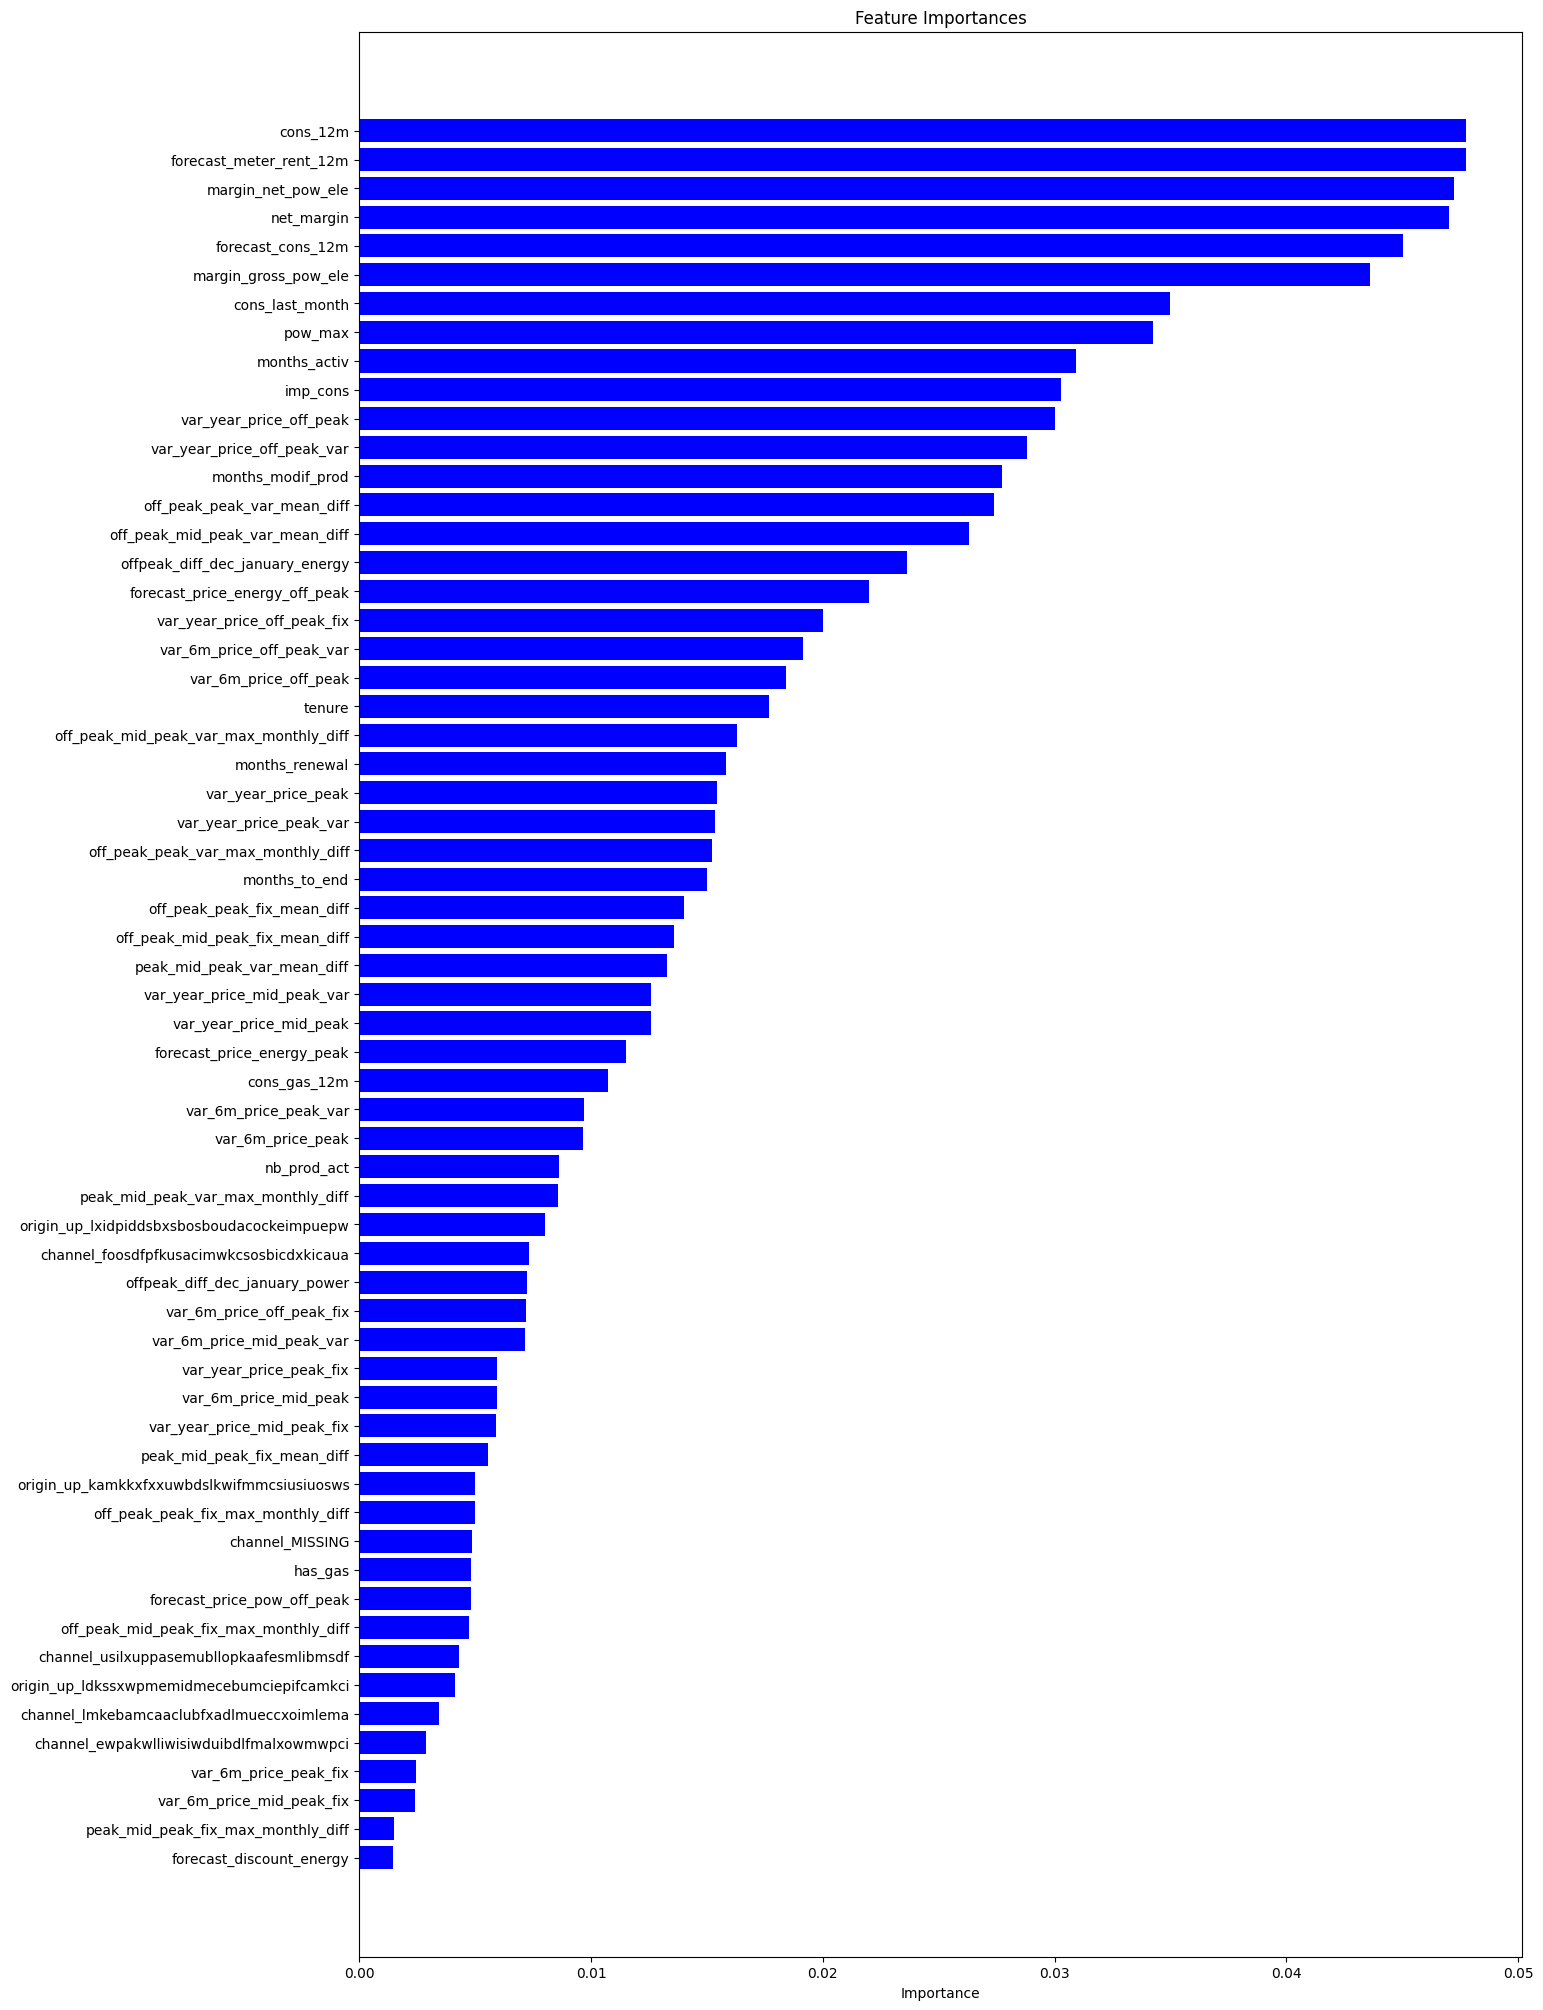

In [ ]:
plt.figure(figsize=(15, 25))
plt.title('Feature Importances')
plt.barh(range(len(feature_importances)), feature_importances['importance'], color='b', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.show()

From this chart, we can observe the following points:

- Net margin and consumption over 12 months is a top driver for churn in this model
- Margin on power subscription also is an influential driver
- Time seems to be an influential factor, especially the number of months they have been active, their tenure and the number of months since they updated their contract
- The feature that our colleague recommended is in the top half in terms of how influential it is and some of the features built off the back of this actually outperform it
- Our price sensitivity features are scattered around but are not the main driver for a customer churning

The last observation is important because this relates back to our original hypothesis:

    > Is churn driven by the customers' price sensitivity?

Based on the output of the feature importances, it is not a main driver but it is a weak contributor. However, to arrive at a conclusive result, more experimentation is needed.

In [ ]:
test_predictions = final_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions).ravel()

In [ ]:
y_test.value_counts()

,count
churn,
0,1304
1,157


In [ ]:
proba_predictions = final_model.predict_proba(X_test)
probabilities = proba_predictions[:, 1]

In [ ]:
X_test = X_test.reset_index()
X_test.drop(columns='index', inplace=True)

In [ ]:
X_test['churn'] = test_predictions.tolist()
X_test['churn_probability'] = probabilities.tolist()
X_test.to_csv('/content/drive/MyDrive/Job Simulations/BCG-X/out_of_sample_data_with_predictions.csv')

###Summarizing Model Evaluation
* We decide how to evaluate the performance of the model. In general, you want to use metrics that reflect honestly how well the model has performed.
* In the example notebook we use 3 metrics, accuracy, precision and recall.
* The reason why we are using these three metrics is because a simple accuracy measure (what percentage was predicted correctly) is not always a good measure to use when there isn't an equal split between categories (e.g., churn is the category we care most about but is only 10% of the data).
* After calculating the 3 metrics, we can see that we’re able to accurately identify clients that do not churn, but not so accurately identify clients that will churn. Our model is predicting a high percentage of clients to not churn, when in fact they did!
* This suggests that more work needs to be done on feature engineering and model tuning to reduce the number of false negatives in our predictions.


Finally, we produce a feature importance chart to visualize which features were indeed useful within the model and which ones weren’t.

* We can see that net margin and consumption over 12 months were important predictors of churn.
* However the price sensitivity features are scattered around and do not shine through as a main driver for churn in their current form.

###Executive Summary
The entire case study deals with how an airline like United Airlines prepares itself to prevent future aircraft failures by using Machine Learning and operational insights. I used ML techniques on top of a dataset with nearly 50K flight records to develop an advanced predictive maintenance system that accurately predicts the probability of an aircraft failure within 30 days. This enables the airline's maintenance team to quickly identify, analyze and make informed decisions on which flights require pre-emptive inspection or intervention. And this in turn helps in minimizing costly unexpected failures and optimizing maintenance schedules.

* See how it beautifully answers all the questions in one flow:
  * ✅What problem did I try to solve?
  * ✅What type of data I used?
  * ✅How I did it?
  * ✅What will potentially happen to the respective team after I did it?

###Business Problem (Why it matters)
For any airline, preventing unexpected aircraft failures is extremely important for safety, operational efficiency, and profitability. If the airline can predict potential failures before they happen, they can schedule maintenance proactively, avoiding costly delays, cancellations, and most importantly, ensuring passenger safety. This problem impacts passengers, maintenance and operations teams, and the airline's overall financial performance and reputation. Building a good predictive maintenance system helps to reduce downtime, lower maintenance costs, improve aircraft utilization, and enhance safety records. If this problem isn't handled well enough, unexpected failures would continue, leading to significant operational disruptions, increased repair costs, and potential safety risks, damaging the airline's credibility and bottom line.

* See how it beautifully answers all the questions in one flow:
  * ✅Why solve this problem and how it matters to the business?
  * ✅Who's affected by this problem?
  * ✅How this solution saves money, reduces risk, improves efficiently?
  * ✅What would happen if this wasn't solved?

###My approach (Story of the build)
Let's walkthrough the approach:

Took the airline maintenance data → cleaned and explored features, noting the imbalance in failure data → looked at flight info, sensor data, environmental factors, and maintenance history → created new features like 'temp_delta', 'stress_score', and 'maintenance_risk' to capture degradation trends and interaction effects → sorted data by aircraft and flight hours to calculate trend features accurately → scaled numerical features and used Target Encoding for categorical ones → split data into train-test sets, ensuring stratification for the imbalanced target → computed class weights to handle imbalance during model training → tried out several models (Logistic Regression, XGBoost, LightGBM, Isolation Forest) → evaluated them based on ROC-AUC and Precision-Recall AUC scores (better for imbalanced data) → Logistic Regression with engineered features had the best PR-AUC and ROC-AUC, outperforming tree-based models and anomaly detection, indicating failures follow mostly linear degradation patterns → Statistical performance metrics that performed to me were: ROC-AUC and PR-AUC (for imbalanced classification), Confusion Matrix (to see False Positives and False Negatives), Classification Report (Precision, Recall, F1-score) → Analyzed feature importance for insights (Logistic Regression coefficients, XGBoost/LightGBM importance) → Calculated business impact based on defined costs for false positives and false negatives → Included cost-sensitive evaluation to find optimal threshold balancing business costs → Prepared executive-level summary and roadmap.

* See how it beautifully answers all the questions in one flow:
  * ✅How did I clean and understand the data?
  * ✅What features did I use/create and why?
  * ✅What models did I try and why did I pick the final one?
  * ✅What metrics mattered to me and the business?
  * ✅How did I handle edge cases like imbalance or drift?

###Model Interpretation (What did I learn?)
Yes, I can explain the working of this predictive maintenance model to a non-technical stakeholder. Basically, we've built a system that helps predict whether an aircraft is at risk of failure within the next 30 days. Think of it like a smart assistant that looks at different pieces of information about a flight and the aircraft's history and gives either a 'green light' (low risk) or a 'red flag' (high risk). How it does that? Essentially, it's using historical data of past flights and maintenance records to learn exactly what characteristics and trends are associated with aircraft failures and which ones are not.
Some factors that stood out were:
Flight hours and cycles (cumulative wear and tear); Sensor data like engine temperature and vibration level (indicators of system health); Environmental/Route factors like turbulence and airport condition (external stress); Maintenance history (recency and quality of last check); Trends and deltas in sensor readings (capturing degradation over time); Combined stress scores (interaction of vibration, turbulence, and airport condition); Maintenance risk score (interaction of days since last check and its quality). Yes, the model's predictions appear logical from a business POV. Why? Analysis shows that the model can significantly reduce expected maintenance costs by flagging high-risk flights for pre-emptive checks. The model focuses on factors known to contribute to mechanical stress and wear. Since the model performed well on test data and its feature importance aligns with domain knowledge, it suggests it learned general patterns of failure rather than just memorizing training examples. For handling bias, we used stratification during the train-test split and class weights/imbalance handling in models to ensure the model doesn't ignore the rare failure cases during training.

* See how it beautifully answers all the questions in one flow:
  * ✅Can I explain the working of this model to a non-technical stakeholder and how do they work?
  * ✅Which features were most important and why?
  * ✅Are the model's predictions logical from a business POV?
  * ✅How did I validate that its not overfitting or biased?

###Business Value
Quantifying the business impact of this model:
* Expected cost with model (threshold 0.4-0.5): ~$4.29M - $4.30M per 50k flights
* Baseline 'do nothing' cost: ~$28.8M per 50k flights (5.76% failure rate * $10k cost per failure)
* Cost reduction: ~85% reduction in expected losses compared to baseline.
* Recall at threshold 0.4: ~86% (catching most failures)
* Precision at threshold 0.4: ~6.6% (manageable false alarms for safety-critical use)

Some of the KPIs relevant to the business purpose were:
Expected Cost (directly measures overall financial impact considering false positives and negatives); Recall (critical for safety - percentage of actual failures correctly identified); Precision (important for operational efficiency - percentage of flagged flights that actually fail); False Positive Rate (cost of unnecessary inspections); False Negative Rate (cost and safety risk of missed failures); ROC-AUC and PR-AUC (overall model discrimination power, especially for rare events).

* See how it beautifully answers all the questions in one flow:
  * ✅Can you quantify the business impact of your model?
  * ✅What KPIs are relevant to the business purpose?

###Future Enhancements (What I'd improve)
If I had more time/data/resources, then I'd definitely work on certain aspects:

Advanced Data/Features → Integrate real-time sensor data streams; Engineer time-series features (e.g., rate of change, cumulative stress cycles); Explore external data sources (e.g., detailed flight logs, specific part histories).

MLOps Integration → Implement automated data pipelines for continuous model retraining; Set up A/B testing for different model versions or thresholds; Develop model monitoring for drift detection (input data characteristics, prediction distributions).

Product Expansion → Apply models to specific critical components (engines, landing gear); Develop prescriptive maintenance recommendations based on failure type; Integrate into fleet management systems for dynamic scheduling.

* See how it beautifully answers all the questions in one flow:
  * ✅What would I do if I had more time/data/resources?

###Monitoring & Maintenance
If the model's performance degrades after it's put into use, it means it's not as good at predicting aircraft failures as it was when we tested it. This results in increased unexpected failures, higher maintenance costs, reduced operational reliability, and potential safety risks, harming the airline's reputation and profitability. Need to keep a track of the key business metrics (KPIs discussed earlier) like unexpected failure rate and maintenance costs. Monitor for data drift, continuously checking if the characteristics of incoming flight and sensor data change significantly. Monitor for prediction drift, tracking how the model's risk scores and predictions are distributed over time. Analyze model explanations periodically to ensure the model is still making decisions based on logical risk factors and that feature importance remains consistent. A/B testing, if possible, comparing the current model with updated versions or alternative approaches on a subset of flights.

* See how it beautifully answers all the questions in one flow:
  * ✅What happens if your model performance degrades?
  * ✅How would you monitor your model post deployment?

###Deployment
This project wasn't deployed. In order to do that, the model and code need to be finalized and packaged (e.g., via Docker container) → set up automated data pipelines (ingesting real-time or near-real-time flight and sensor data to produce risk scores) → build APIs (creating endpoints for the model to be accessed by other systems like maintenance scheduling software or operational dashboards) → host the APIs on cloud platforms (like AWS, Azure, or GCP) → integrate the deployed API with United Airlines' existing operational systems (fleet management, maintenance planning, pilot reporting tools).

###Reflections & Takeaways
Good models make predictions, great models provide actionable insights – being able to explain *why* a flight is high-risk helps maintenance teams target inspections effectively.

It's not just about building a model with high statistical scores – it's about building a solution that solves a specific business problem and provides tangible value, so understanding the operational context and cost implications is crucial.

Simple models can be powerful – sometimes a well-engineered linear model captures the core dynamics better than complex non-linear ones, offering interpretability crucial for business adoption.

* See how it beautifully answers all the questions in one flow:
  * ✅What did you takeaway from this entire project?

### Executive Summary
This case study focuses on analyzing customer churn for PowerCo, a major gas and electricity utility supplying small and medium-sized enterprises. Using machine learning techniques on customer, churn, and price data, we developed a binary classification model to understand the drivers of churn and assess the influence of price sensitivity. By identifying key factors influencing churn, PowerCo can proactively target at-risk customers and optimize strategies to improve retention, minimize costly churn, and enhance overall profitability.

* See how it beautifully answers all the questions in one flow:
  * ✅What problem did I try to solve?
  * ✅What type of data I used?
  * ✅How I did it?
  * ✅What will potentially happen to the respective team after I did it?

### Business Problem (Why it matters)
For PowerCo, customer churn represents a significant threat to revenue and market share, especially in a competitive energy market. Understanding why customers leave is crucial for developing effective retention strategies. Price sensitivity is hypothesized as a major driver, but other factors may also play a significant role. High churn rates lead to lost revenue, increased acquisition costs for new customers, and potential damage to the company's reputation. Addressing this problem allows PowerCo to retain valuable customers, improve customer lifetime value, and maintain a strong market position. Failure to address churn effectively would result in continued loss of customers to competitors, diminishing profitability, and a weakened competitive stance.

* See how it beautifully answers all the questions in one flow:
  * ✅Why solve this problem and how it matters to the business?
  * ✅Who's affected by this problem?
  * ✅How this solution saves money, reduces risk, improves efficiently?
  * ✅What would happen if this wasn't solved?

### My approach (Story of the build)
Let's walkthrough the approach:

Took the PowerCo customer, churn, and price data → performed extensive Exploratory Data Analysis (EDA) to understand data distributions, identify missing values, and visualize potential relationships with churn → handled categorical features by converting them to dummy variables and removing low-frequency categories (e.g., `channel_sales`, `origin_up`) → engineered new features from date columns (e.g., `tenure`, `months_activ`, `months_to_end`, `months_modif_prod`, `months_renewal`) to capture temporal aspects of customer behavior → created features related to price changes (average and maximum monthly differences) across different periods (off-peak, peak, mid-peak) to quantify price sensitivity → applied logarithmic transformations to skewed numerical features to achieve a more normal distribution, addressing model assumptions and improving convergence speed → analyzed feature correlations to identify and remove highly correlated independent variables (e.g., `num_years_antig`, `forecast_cons_year`) → separated features (X) and target variable (y - churn) → split data into train, validation, and test sets (70/20/10 ratio) with stratification to handle class imbalance → trained a Random Forest Classifier model, leveraging its ability to handle non-linear relationships and lack of feature scaling requirement → used RandomizedSearchCV with cross-validation to find the best model hyperparameters (`n_estimators`, `max_features`) → evaluated the final model on the validation set using Accuracy, Precision, and Recall metrics, highlighting the limitations of accuracy for imbalanced data and the importance of Recall for identifying churners → analyzed feature importances to understand the key drivers of churn according to the model.

* See how it beautifully answers all the questions in one flow:
  * ✅How did I clean and understand the data?
  * ✅What features did I use/create and why?
  * ✅What models did I try and why did I pick the final one?
  * ✅What metrics mattered to me and the business?
  * ✅How did I handle edge cases like imbalance or drift?

### Model Interpretation (What did I learn?)
Yes, I can explain the working of this churn prediction model to a non-technical stakeholder. Essentially, the model analyzes various pieces of information about a customer to determine how likely they are to stop using PowerCo's services (churn). It's like a system that looks at past customer behaviors and characteristics to identify patterns associated with churning customers. Some factors that were particularly important in predicting churn were:
Net margin and consumption over 12 months (indicating customer value and usage patterns); Margin on power subscription (related to profitability); Tenure and months active (indicating loyalty and relationship duration); Months since last product modification and renewal (indicating engagement and satisfaction); Price sensitivity features, including average and maximum monthly price differences (capturing how customers react to price changes). Yes, the model's predictions appear logical from a business POV. The key drivers identified align with intuitive business understanding (e.g., lower engagement, shorter tenure, certain consumption patterns might indicate higher churn risk). While price sensitivity was not the *main* driver in this model, it did contribute, supporting the initial hypothesis as a contributing factor. The model was evaluated on a separate validation set and feature importances align with some expected patterns, suggesting it's not simply overfitting. Class imbalance was handled by stratifying the data split, ensuring representation of churners in all sets.

* See how it beautifully answers all the questions in one flow:
  * ✅Can I explain the working of this model to a non-technical stakeholder and how do they work?
  * ✅Which features were most important and why?
  * ✅Are the model's predictions logical from a business POV?
  * ✅How did I validate that its not overfitting or biased?

### Business Value
Quantifying the business impact of this model:
The primary business value lies in the ability to identify customers at high risk of churning. By predicting churn, PowerCo can implement targeted retention campaigns or interventions. While specific cost savings would require PowerCo's internal data on customer acquisition and churn costs, the model enables:
* Proactive customer retention efforts: Focusing resources on customers most likely to leave.
* Optimized marketing spend: Tailoring offers or communications based on churn risk.
* Improved customer lifetime value: Retaining valuable customers for longer periods.
* Reduced acquisition costs: Minimizing the need to constantly replace churned customers.
* Enhanced profitability: Protecting revenue streams from existing customers.

Some of the KPIs relevant to the business purpose were:
Recall (critical for identifying as many churners as possible to target for retention); Precision (important for efficient use of retention resources – minimizing interventions on customers who wouldn't churn anyway); Churn Rate (overall measure of the problem we are addressing); Customer Lifetime Value (CLTV) (impacted by successful retention); Customer Acquisition Cost (CAC) (reduced by retaining existing customers); Return on Investment (ROI) of retention campaigns (directly influenced by the model's ability to accurately identify at-risk customers).

* See how it beautifully answers all the questions in one flow:
  * ✅Can you quantify the business impact of your model?
  * ✅What KPIs are relevant to the business purpose?

### Future Enhancements (What I'd improve)
If I had more time/data/resources, then I'd definitely work on certain aspects:

Advanced Feature Engineering → Explore interaction effects between more features; Incorporate external economic data or competitor pricing information; Analyze text data from customer interactions (if available) for sentiment analysis.

Model Improvement & Tuning → Experiment with other classification algorithms (e.g., Gradient Boosting Machines, Logistic Regression with different regularization); Perform more extensive hyperparameter tuning using GridSearchCV; Investigate ensemble methods or stacking for potentially improved performance.

Threshold Optimization → Analyze the cost-benefit trade-off of different probability thresholds for classifying churners to find the optimal point for business impact.

Deployment & Monitoring → Implement a pipeline for regular model retraining on new data; Set up monitoring for model performance drift over time; Integrate the model's predictions into PowerCo's CRM or customer management systems for actionable insights by sales and marketing teams.

* See how it beautifully answers all the questions in one flow:
  * ✅What would I do if I had more time/data/resources?

### Monitoring & Maintenance
If the model's performance degrades after deployment, it means it's becoming less effective at identifying potential churners. This would lead to a decrease in the success rate of retention campaigns, continued high churn rates, and a reduced return on investment for the churn prediction system. To monitor performance post-deployment, we would: Keep track of key business metrics (KPIs discussed earlier) such as the actual churn rate of customers flagged by the model versus those not flagged. Continuously monitor the distribution of the model's predicted churn probabilities for signs of drift. Analyze feature distributions of incoming data to detect data drift, which could indicate changes in customer behavior or data collection processes. Periodically re-evaluate the model's precision and recall on new, unseen data to ensure it maintains its predictive power. Set up alerts for significant drops in performance metrics.

* See how it beautifully answers all the questions in one flow:
  * ✅What happens if your model performance degrades?
  * ✅How would you monitor your model post deployment?

### Deployment
This project was not deployed. In order to do that, the finalized model and associated code would need to be packaged (e.g., using a containerization tool like Docker) → establish automated data pipelines to feed updated customer and price data to the model for scoring → create an API endpoint that allows PowerCo's internal systems (like CRM or marketing automation platforms) to request churn predictions for specific customers or batches of customers → host the deployed model and API on a cloud platform or PowerCo's existing infrastructure, ensuring scalability and reliability → integrate the model's predictions into relevant business workflows, such as triggering automated emails for high-risk customers or providing lists to the sales team for personalized outreach.

### Reflections & Takeaways
Understanding the business problem and stakeholder needs is paramount – a technically sound model is only valuable if it provides actionable insights that address the core business challenge.

Feature engineering, especially creating features that capture behavioral changes over time and price sensitivity, is crucial for building a robust churn prediction model in this domain.

Model evaluation should go beyond simple accuracy, particularly in imbalanced datasets, focusing on metrics like precision and recall that align with the business objectives (e.g., minimizing false negatives to capture more churners).

Interpreting model results and explaining feature importances to non-technical stakeholders is key for building trust and enabling effective utilization of the model's insights.
* See how it beautifully answers all the questions in one flow:
  * ✅What did you takeaway from this entire project?